# Branchiness Analysis

This notebook explores how cloud branchiness varies with size, peak vertical velocity, lifetime-integrated mass flux, and post-peak evolution in the RICO tracking output.

In [ ]:
"""
Shared data loading and per-track metric computation.

This cell loads the cloud-tracking output and assembles the per-track
metrics reused across the figure cells below.

═══════════════════════════════════════════════════════════════════════
ASSUMPTIONS & CLOUD POPULATION
═══════════════════════════════════════════════════════════════════════

  Grid configuration (RICO):
    • DX = DY = DZ = 25 m              (isotropic)
    • DT = 60 s = 1 min                (output cadence)
    • VOXEL_VOL = 15,625 m³

  Surface area & branchiness:
    • surface_area field is in m²       (confirmed: B ≈ 1.2–1.5)
    • B = SA_actual / SA_sphere, where SA_sphere = 4π(3V/4π)^(2/3)

  Lifetime definition:
    • Track length = NUMBER OF ACTIVE TIMESTEPS (size > 0 and finite)
    • We do NOT use the 'age' variable from the NetCDF, because age
      inherits from merge-winner parents and can exceed the track's
      own lifespan.
    • lifetime_min = active_timestep_count × DT_MIN

  Which clouds are included:
    • valid_track == 1  (complete birth-to-death lifecycle)
      NOTE: the NetCDF file pre-allocates 100k rows. Unfilled rows
      also have valid_track=1 by default, so we ALSO require that
      the track has ≥1 active timestep (finite, nonzero size).
    • max_size ≥ MIN_SIZE_PTS (10 voxels) — filter out noise

  Fragment identification:
    • split_from > 0 at the track's first active timestep means the
      cloud was born via a split event (it's a fragment/child).

  What's NOT filtered:
    • We include BOTH fragments and non-fragments by default.
    • Subsequent figures break these out where needed.
═══════════════════════════════════════════════════════════════════════

OUTPUT OBJECTS:
  raw        — dict of raw NetCDF arrays, shape (track, time) or (track, time, level)
  df_section — pandas DataFrame, one row per valid cloud, with columns:
      track_index, lifetime_min, max_size, mean_size,
      max_vol_m3, mean_vol_m3, max_r_eq, mean_r_eq,
      max_w, mean_B, max_B, J_i, is_fragment,
      merges_total, splits_total, peak_w_idx, is_detached,
      tau_d, tau_d_r2, n_postpeak, peak_mf_idx
"""

# ── Configuration ──────────────────────────────────────────────────────────
NC_FILE      = "../output_archive/cloud_results_120mins.nc"
DX           = 25.0           # horizontal grid spacing (m)
DY           = 25.0
DZ           = 25.0           # vertical grid spacing (m) — uniform in RICO
DT_S         = 60.0           # output timestep (seconds)
DT_MIN       = DT_S / 60.0   # output timestep (minutes) = 1.0

VOXEL_VOL    = DX * DY * DZ  # 15 625 m³

# Quality filters
MIN_SIZE_PTS       = 10       # track must reach ≥ this many voxels at some point
MIN_LIFETIME_STEPS = 1        # minimum lifetime (timesteps)

# Decay-rate fit parameters
MIN_POSTPEAK       = 3        # minimum number of timesteps AFTER peak MF
R2_THRESHOLD       = 0.5      # discard fits with R² below this

# Detachment parameters (diagnosed method)
LCL_HEIGHT         = 700.0    # RICO LCL (m)
DETACH_THRESHOLD   = 50.0     # cloud base must rise > this above initial height

# ── Imports ────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LogNorm, LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
from netCDF4 import Dataset
from scipy.stats import linregress, mannwhitneyu, pearsonr, spearmanr
from scipy.optimize import curve_fit
import seaborn as sns
import warnings

FS = 16
plt.rcParams.update({'font.size': FS})

# ── Load raw data ──────────────────────────────────────────────────────────
def _read(ds, name):
    """Read a NetCDF variable, converting masked values to NaN.
       Integer arrays are cast to float first (NaN is a float concept)."""
    v = ds.variables.get(name)
    if v is None:
        return None
    arr = v[:]
    if hasattr(arr, 'filled'):
        return arr.astype(float).filled(np.nan)
    return np.asarray(arr, dtype=float)

with Dataset(NC_FILE) as ds:
    raw = dict(
        valid_track   = np.asarray(ds.variables['valid_track'][:]),
        size          = _read(ds, 'size'),
        mass_flux     = _read(ds, 'mass_flux'),
        surface_area  = _read(ds, 'surface_area'),
        max_w         = _read(ds, 'max_w'),
        max_height    = _read(ds, 'max_height'),
        max_equiv_radius = _read(ds, 'max_equiv_radius'),
        merges_count  = _read(ds, 'merges_count'),
        splits_count  = _read(ds, 'splits_count'),
        split_from    = np.ma.filled(ds.variables['split_from'][:].astype(float), -999.0),
        height        = np.asarray(ds.variables['height'][:]),
        compactness_per_level = _read(ds, 'compactness_per_level'),
        cloud_base_height = _read(ds, 'cloud_base_height'),
    )

n_tracks, n_time = raw['size'].shape

# ── Identify truly filled tracks vs empty pre-allocated rows ───────────────
has_any_data = np.any(np.isfinite(raw['size']) & (raw['size'] > 0), axis=1)
n_filled = np.sum(has_any_data)
n_empty  = n_tracks - n_filled
n_valid_flag = np.sum(raw['valid_track'] == 1)
n_tainted    = np.sum(raw['valid_track'] == 0)

print(f"NetCDF shape: {n_tracks} tracks × {n_time} timesteps")
print(f"  Rows with actual cloud data: {n_filled:,}")
print(f"  Empty pre-allocated rows   : {n_empty:,}")
print(f"  valid_track == 1           : {n_valid_flag:,}  "
      f"(includes {n_valid_flag - n_filled:,} empty rows)")
print(f"  valid_track == 0 (tainted) : {n_tainted:,}")

# ── Build per-track DataFrame ──────────────────────────────────────────────
records = []

for i in range(n_tracks):
    # 1. Must have valid_track flag
    if raw['valid_track'][i] != 1:
        continue

    # 2. Must have actual data (not an empty pre-allocated row)
    size_row = raw['size'][i]                       # (n_time,)
    active   = np.isfinite(size_row) & (size_row > 0)
    active_idx = np.where(active)[0]
    lifetime = active_idx.size

    if lifetime < MIN_LIFETIME_STEPS:
        continue

    # 3. Size filter
    max_size = np.nanmax(size_row[active])
    if max_size < MIN_SIZE_PTS:
        continue

    # ─── Timing (from track length, NOT the age variable) ──────────────
    lifetime_min = lifetime * DT_MIN

    # ─── Size, volume & equivalent radius ──────────────────────────────
    vol_m3     = size_row[active] * VOXEL_VOL                    # m³
    r_eq       = (3.0 * vol_m3 / (4.0 * np.pi)) ** (1.0 / 3.0)  # m
    mean_r_eq  = float(np.nanmean(r_eq))
    max_r_eq   = float(np.nanmax(r_eq))
    mean_size  = float(np.nanmean(size_row[active]))
    max_vol_m3 = float(np.nanmax(vol_m3))
    mean_vol_m3 = float(np.nanmean(vol_m3))

    # ─── Branchiness time series ───────────────────────────────────────
    sa_row     = raw['surface_area'][i, :]                       # m²
    sphere_sa  = 4.0 * np.pi * (3.0 * size_row * VOXEL_VOL
                                 / (4.0 * np.pi)) ** (2.0 / 3.0)
    with np.errstate(divide='ignore', invalid='ignore'):
        B_series = np.where(sphere_sa > 0, sa_row / sphere_sa, np.nan)

    mean_B = float(np.nanmean(B_series[active]))
    max_B  = float(np.nanmax(B_series[active]))

    # ─── Peak branchiness timing ──────────────────────────────────────
    B_active = B_series[active]
    finite_B = np.isfinite(B_active)
    if finite_B.any():
        peak_B_local = int(np.nanargmax(B_active))
        peak_B_idx = active_idx[peak_B_local]
        # Normalised timing: 0 = birth, 1 = death
        peak_B_norm = peak_B_local / max(lifetime - 1, 1)
    else:
        peak_B_idx = np.nan
        peak_B_norm = np.nan

    # ─── Max vertical velocity ─────────────────────────────────────────
    mw = raw['max_w'][i, :]
    max_w_val = float(np.nanmax(mw[active]))

    # ─── Lifetime-integrated mass flux J_i ─────────────────────────────
    mf_row = raw['mass_flux'][i, :]
    J_i = float(np.nansum(mf_row[active]) * DT_S)               # kg

    # ─── Merge / split bookkeeping ─────────────────────────────────────
    merges_total = int(np.nansum(raw['merges_count'][i, active]))
    splits_total = int(np.nansum(raw['splits_count'][i, active]))

    # ─── Fragment flag ─────────────────────────────────────────────────
    birth_t = active_idx[0]
    is_frag = raw['split_from'][i, birth_t] > 0

    # ─── Peak w timing (for violin analyses) ──────────────────────────
    mw_active = mw[active]
    if np.any(mw_active > 0):
        peak_w_local = int(np.nanargmax(mw_active))
        peak_w_idx = active_idx[peak_w_local]
    else:
        peak_w_idx = np.nan

    # ─── Detachment flag (diagnosed method) ────────────────────────────
    cbh_row = raw['cloud_base_height'][i, :]
    cbh_active = cbh_row[active]
    is_detached = False
    if np.any(np.isfinite(cbh_active)):
        initial_cbh = cbh_active[np.isfinite(cbh_active)][0]
        max_rise = np.nanmax(cbh_active) - initial_cbh
        is_detached = max_rise > DETACH_THRESHOLD

    # ─── Peak mass flux timing ─────────────────────────────────────────
    mf_active = mf_row[active]
    if np.any(mf_active > 0):
        peak_local = int(np.nanargmax(mf_active))
        peak_mf_idx = active_idx[peak_local]
        M_peak = mf_active[peak_local]
    else:
        peak_mf_idx = np.nan
        M_peak = np.nan

    # ─── Universal decay metrics (work for ALL clouds) ───────────────
    # Remaining lifetime after peak mass flux (minutes)
    if np.isfinite(peak_mf_idx):
        time_after_peak_mf = (active_idx[-1] - int(peak_mf_idx)) * DT_MIN
    else:
        time_after_peak_mf = np.nan

    # Remaining lifetime after peak w (minutes)
    if np.isfinite(peak_w_idx):
        time_after_peak_w = (active_idx[-1] - int(peak_w_idx)) * DT_MIN
    else:
        time_after_peak_w = np.nan

    # Remaining lifetime after peak volume (minutes)
    peak_vol_local = int(np.nanargmax(size_row[active]))
    peak_vol_idx = active_idx[peak_vol_local]
    time_after_peak_vol = (active_idx[-1] - peak_vol_idx) * DT_MIN

    # Fraction of lifetime spent in decay (post-peak-MF / total)
    if np.isfinite(peak_mf_idx) and lifetime > 1:
        frac_decay = time_after_peak_mf / lifetime_min
    else:
        frac_decay = np.nan

    # Post-peak flux integral (continuous decay metric, minutes)
    # I_post = Σ M(t)·Δt / M_peak, from t_peak to t_death
    # Equivalent to remaining lifetime weighted by how much flux is retained.
    if np.isfinite(peak_mf_idx) and np.isfinite(M_peak) and M_peak > 0:
        _pfi_mask = active_idx >= int(peak_mf_idx)
        _pfi_mf = mf_row[active_idx[_pfi_mask]]
        postpeak_flux_integral = float(np.nansum(_pfi_mf) * DT_S / M_peak / 60.0)
    else:
        postpeak_flux_integral = np.nan

    # ─── Decay e-folding time τ_d (kept for reference) ────────────────
    tau_d    = np.nan
    tau_d_r2 = np.nan
    n_postpeak = 0

    if np.isfinite(peak_mf_idx):
        peak_mf_idx_int = int(peak_mf_idx)
        post_mask = active_idx >= peak_mf_idx_int
        post_idx  = active_idx[post_mask]
        post_mf   = mf_row[post_idx]

        pos_mask = post_mf > 0
        if not pos_mask.all():
            first_nonpos = np.argmin(pos_mask)
            if first_nonpos == 0:
                post_idx = np.array([], dtype=int)
                post_mf  = np.array([])
            else:
                post_idx = post_idx[:first_nonpos]
                post_mf  = post_mf[:first_nonpos]

        n_postpeak = max(0, len(post_idx) - 1)

        if n_postpeak >= MIN_POSTPEAK:
            x = (post_idx - peak_mf_idx_int).astype(float) * DT_MIN
            y = np.log(post_mf)
            try:
                slope, intercept, r_val, _, _ = linregress(x, y)
            except Exception:
                slope = 0.0
                r_val = 0.0

            r2 = r_val ** 2
            if slope < 0 and r2 >= R2_THRESHOLD:
                tau_d    = -1.0 / slope
                tau_d_r2 = r2

    records.append(dict(
        track_index   = i,
        lifetime_min  = lifetime_min,
        max_size      = max_size,
        mean_size     = mean_size,
        max_vol_m3    = max_vol_m3,
        mean_vol_m3   = mean_vol_m3,
        max_r_eq      = max_r_eq,
        mean_r_eq     = mean_r_eq,
        max_w         = max_w_val,
        mean_B        = mean_B,
        max_B         = max_B,
        J_i           = J_i,
        is_fragment   = is_frag,
        merges_total  = merges_total,
        splits_total  = splits_total,
        peak_w_idx    = peak_w_idx if np.isfinite(peak_w_idx) else np.nan,
        peak_B_idx    = peak_B_idx if np.isfinite(peak_B_idx) else np.nan,
        peak_B_norm   = peak_B_norm,
        is_detached   = is_detached,
        time_after_peak_mf  = time_after_peak_mf,
        time_after_peak_w   = time_after_peak_w,
        time_after_peak_vol = time_after_peak_vol,
        postpeak_flux_integral = postpeak_flux_integral,
        frac_decay    = frac_decay,
        tau_d         = tau_d,
        tau_d_r2      = tau_d_r2,
        n_postpeak    = n_postpeak,
        peak_mf_idx   = peak_mf_idx,
    ))

df_section = pd.DataFrame.from_records(records)

# ── Summary statistics ─────────────────────────────────────────────────────
n_total = len(df_section)
n_decay = df_section['tau_d'].notna().sum()
n_frag  = df_section['is_fragment'].sum()
print(f"\n{'='*60}")
print(f"Section 3.6 cloud population")
print(f"{'='*60}")
print(f"Filters applied:")
print(f"  1. valid_track == 1 (complete lifecycle)")
print(f"  2. ≥ {MIN_LIFETIME_STEPS} active timestep(s)")
print(f"  3. max size ≥ {MIN_SIZE_PTS} voxels ({MIN_SIZE_PTS * VOXEL_VOL:.0f} m³)")
print(f"  4. Lifetime = count of active timesteps × {DT_MIN} min")
print(f"     (NOT the NetCDF 'age' field, which inherits from merges)")
print(f"\nResult:")
print(f"  Total clouds passing filters       : {n_total:,}")
print(f"    Fragments (split-off births)     : {n_frag:,} ({100*n_frag/n_total:.1f}%)")
print(f"    Non-fragments                    : {n_total - n_frag:,} ({100*(n_total-n_frag)/n_total:.1f}%)")
print(f"  Clouds with valid τ_d fit          : {n_decay:,} ({100*n_decay/n_total:.1f}%)")
print(f"    (R² ≥ {R2_THRESHOLD}, ≥ {MIN_POSTPEAK} post-peak steps)")
print(f"\nLifetime distribution (minutes, = track length × DT):")
print(f"  median = {df_section['lifetime_min'].median():.1f},  "
      f"IQR = [{df_section['lifetime_min'].quantile(0.25):.1f}, "
      f"{df_section['lifetime_min'].quantile(0.75):.1f}],  "
      f"range = [{df_section['lifetime_min'].min():.1f}, "
      f"{df_section['lifetime_min'].max():.1f}]")
print(f"\nτ_d distribution (minutes):")
valid_tau = df_section.loc[df_section['tau_d'].notna(), 'tau_d']
if len(valid_tau) > 0:
    print(f"  median = {valid_tau.median():.2f},  mean = {valid_tau.mean():.2f}")
    print(f"  IQR    = [{valid_tau.quantile(0.25):.2f}, {valid_tau.quantile(0.75):.2f}]")
    print(f"  range  = [{valid_tau.min():.2f}, {valid_tau.max():.2f}]")
print(f"\nBranchiness (mean_B over life):")
print(f"  median = {df_section['mean_B'].median():.3f},  "
      f"IQR = [{df_section['mean_B'].quantile(0.25):.3f}, "
      f"{df_section['mean_B'].quantile(0.75):.3f}]")
print(f"\nMax volume (m³):")
print(f"  median = {df_section['max_vol_m3'].median():.0f},  "
      f"IQR = [{df_section['max_vol_m3'].quantile(0.25):.0f}, "
      f"{df_section['max_vol_m3'].quantile(0.75):.0f}]")
print(f"\nMax equivalent radius (m):")
print(f"  median = {df_section['max_r_eq'].median():.1f},  "
      f"IQR = [{df_section['max_r_eq'].quantile(0.25):.1f}, "
      f"{df_section['max_r_eq'].quantile(0.75):.1f}]")

# Universal decay metrics coverage
n_tapmf = df_section['time_after_peak_mf'].notna().sum()
n_tapw  = df_section['time_after_peak_w'].notna().sum()
n_tapv  = df_section['time_after_peak_vol'].notna().sum()
print(f"\nDecay metric coverage:")
print(f"  τ_d (exp fit, R²≥{R2_THRESHOLD})      : {n_decay:>6,} ({100*n_decay/n_total:.1f}%)")
print(f"  time_after_peak_mf (universal)   : {n_tapmf:>6,} ({100*n_tapmf/n_total:.1f}%)")
print(f"  time_after_peak_w  (universal)   : {n_tapw:>6,} ({100*n_tapw/n_total:.1f}%)")
print(f"  time_after_peak_vol (universal)  : {n_tapv:>6,} ({100*n_tapv/n_total:.1f}%)")
n_pfi = df_section['postpeak_flux_integral'].notna().sum()
print(f"  postpeak_flux_integral (new)     : {n_pfi:>6,} ({100*n_pfi/n_total:.1f}%)")

tapmf = df_section.loc[df_section['time_after_peak_mf'].notna(), 'time_after_peak_mf']
if len(tapmf) > 0:
    print(f"\nTime after peak MF (minutes):")
    print(f"  median = {tapmf.median():.1f},  IQR = [{tapmf.quantile(0.25):.1f}, {tapmf.quantile(0.75):.1f}]")

pfi = df_section.loc[df_section['postpeak_flux_integral'].notna(), 'postpeak_flux_integral']
if len(pfi) > 0:
    print(f"\nPost-peak flux integral (minutes):")
    print(f"  median = {pfi.median():.2f},  IQR = [{pfi.quantile(0.25):.2f}, {pfi.quantile(0.75):.2f}]")
    print(f"  range  = [{pfi.min():.2f}, {pfi.max():.2f}]")

NetCDF shape: 100000 tracks × 179 timesteps
  Rows with actual cloud data: 36,451
  Empty pre-allocated rows   : 63,549
  valid_track == 1           : 94,976  (includes 58,525 empty rows)
  valid_track == 0 (tainted) : 5,024

Section 3.6 cloud population
Filters applied:
  1. valid_track == 1 (complete lifecycle)
  2. ≥ 1 active timestep(s)
  3. max size ≥ 10 voxels (156250 m³)
  4. Lifetime = count of active timesteps × 1.0 min
     (NOT the NetCDF 'age' field, which inherits from merges)

Result:
  Total clouds passing filters       : 31,427
    Fragments (split-off births)     : 24,972 (79.5%)
    Non-fragments                    : 6,455 (20.5%)
  Clouds with valid τ_d fit          : 4,398 (14.0%)
    (R² ≥ 0.5, ≥ 3 post-peak steps)

Lifetime distribution (minutes, = track length × DT):
  median = 2.0,  IQR = [1.0, 5.0],  range = [1.0, 67.0]

τ_d distribution (minutes):
  median = 1.37,  mean = 1.79
  IQR    = [0.92, 2.08]
  range  = [0.25, 95.10]

Branchiness (mean_B over life):
  

### Branchiness basics

A first pass through the dataset:
- Where does peak branchiness fall within a cloud lifetime?
- How does peak branchiness line up with peak updraft and peak volume?
- Do fragment and non-fragment tracks show different timing?

Clouds with ≥ 3 min lifetime: 13,569


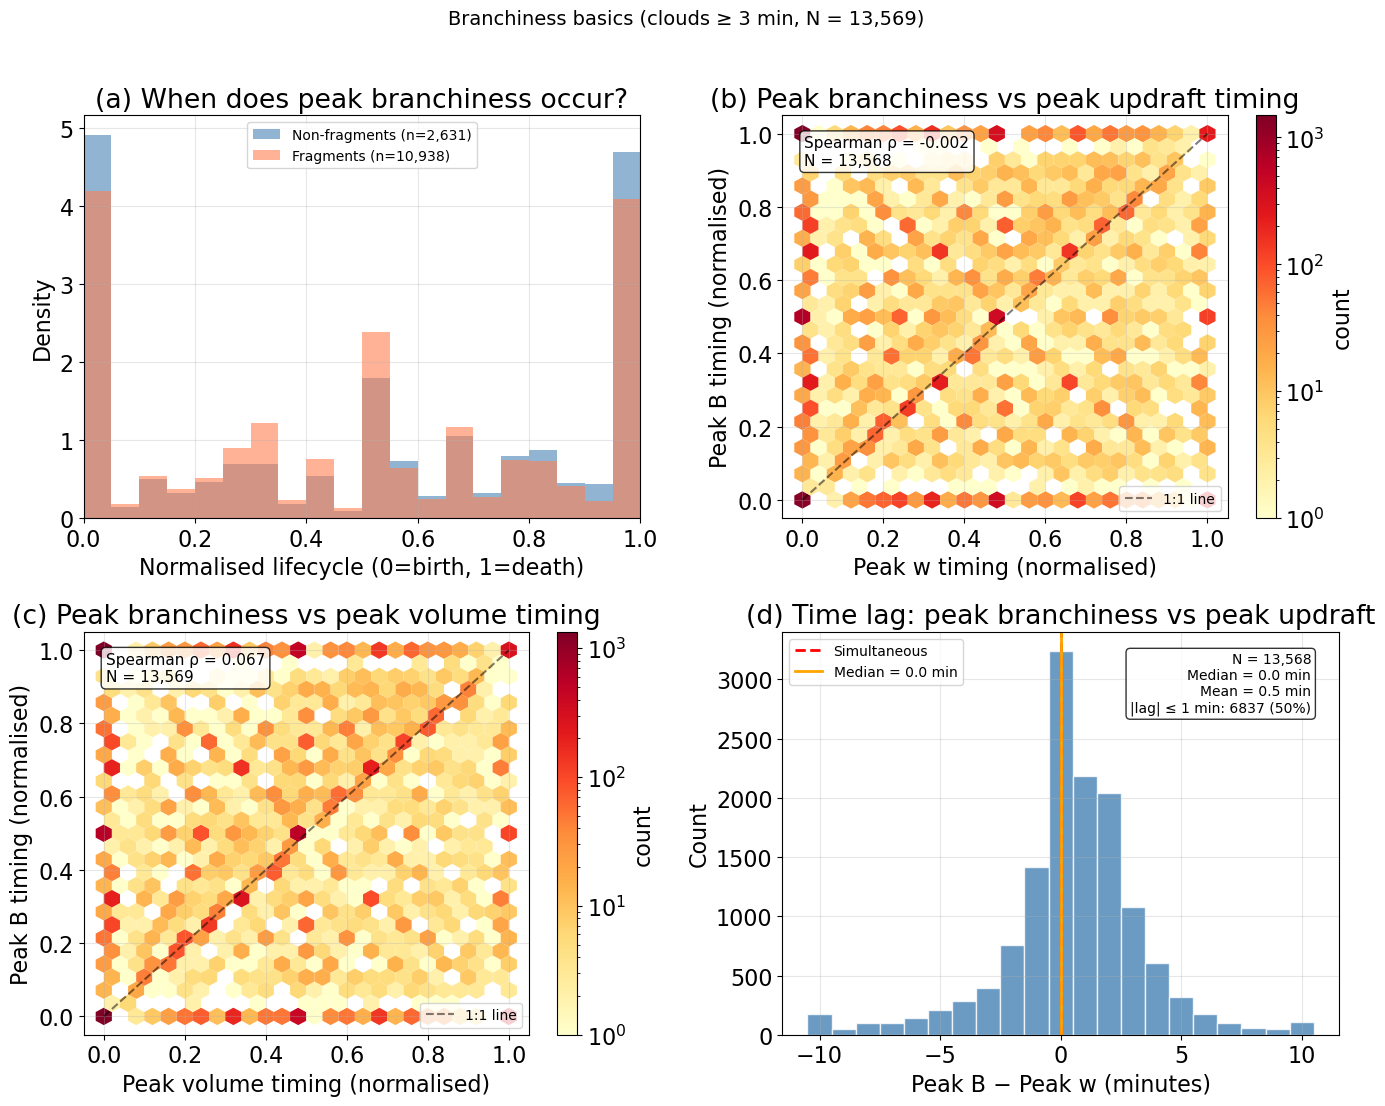

In [5]:
"""
Branchiness basics — timing of peak B relative to lifecycle and other peaks.

Panel (a): Histogram of normalised peak-B timing (0=birth, 1=death).
Panel (b): Peak B timing vs peak w timing (normalised).
Panel (c): Peak B timing vs peak volume timing (normalised).
Panel (d): Distribution of time lag (peak_B − peak_w) in minutes.
"""

# ── Require ≥ 3 min lifetime so normalised timing is meaningful ───────────
MIN_LIFE_BASIC = 3
df_basic = df_section[df_section['lifetime_min'] >= MIN_LIFE_BASIC].copy()

# Normalised peak timing for w and volume
lifetime_steps = df_basic['lifetime_min'] / DT_MIN  # number of active steps

# peak_w normalised
df_basic['peak_w_norm'] = np.nan
mask_pw = df_basic['peak_w_idx'].notna()
for idx in df_basic.index[mask_pw]:
    i = int(df_basic.loc[idx, 'track_index'])
    size_row = raw['size'][i]
    active_idx = np.where(np.isfinite(size_row) & (size_row > 0))[0]
    lt = len(active_idx)
    if lt > 1:
        pw = int(df_basic.loc[idx, 'peak_w_idx'])
        local_pos = np.searchsorted(active_idx, pw)
        df_basic.loc[idx, 'peak_w_norm'] = local_pos / (lt - 1)

# peak_vol normalised
df_basic['peak_vol_norm'] = np.nan
for idx in df_basic.index:
    i = int(df_basic.loc[idx, 'track_index'])
    size_row = raw['size'][i]
    active_idx = np.where(np.isfinite(size_row) & (size_row > 0))[0]
    lt = len(active_idx)
    if lt > 1:
        peak_loc = int(np.nanargmax(size_row[active_idx]))
        df_basic.loc[idx, 'peak_vol_norm'] = peak_loc / (lt - 1)

# Time lag (peak_B − peak_w) in minutes
df_basic['lag_B_w_min'] = np.nan
mask_both = df_basic['peak_B_idx'].notna() & df_basic['peak_w_idx'].notna()
df_basic.loc[mask_both, 'lag_B_w_min'] = (
    df_basic.loc[mask_both, 'peak_B_idx'] - df_basic.loc[mask_both, 'peak_w_idx']
) * DT_MIN

print(f"Clouds with ≥ {MIN_LIFE_BASIC} min lifetime: {len(df_basic):,}")

# ── Figure ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# (a) Histogram of normalised peak-B timing
ax = axes[0, 0]
mask_bn = df_basic['peak_B_norm'].notna()
is_frag_mask = df_basic['is_fragment'].astype(bool)

ax.hist(df_basic.loc[mask_bn & ~is_frag_mask, 'peak_B_norm'], bins=20,
        alpha=0.6, color='steelblue', density=True,
        label=f'Non-fragments (n={int((mask_bn & ~is_frag_mask).sum()):,})')
ax.hist(df_basic.loc[mask_bn & is_frag_mask, 'peak_B_norm'], bins=20,
        alpha=0.6, color='coral', density=True,
        label=f'Fragments (n={int((mask_bn & is_frag_mask).sum()):,})')
ax.set_xlabel('Normalised lifecycle (0=birth, 1=death)')
ax.set_ylabel('Density')
ax.set_title('(a) When does peak branchiness occur?')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)

# (b) Peak B timing vs peak w timing
ax = axes[0, 1]
mask_both_norm = df_basic['peak_B_norm'].notna() & df_basic['peak_w_norm'].notna()
x_b = df_basic.loc[mask_both_norm, 'peak_w_norm'].values
y_b = df_basic.loc[mask_both_norm, 'peak_B_norm'].values
hb = ax.hexbin(x_b, y_b, gridsize=25, cmap='YlOrRd', mincnt=1,
               norm=LogNorm(), edgecolors='none')
plt.colorbar(hb, ax=ax, label='count')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='1:1 line')
rho_bw, _ = spearmanr(x_b, y_b)
ax.text(0.05, 0.95, f'Spearman ρ = {rho_bw:.3f}\nN = {len(x_b):,}',
        transform=ax.transAxes, fontsize=11, va='top',
        bbox=dict(boxstyle='round', fc='white', alpha=0.8))
ax.set_xlabel('Peak w timing (normalised)')
ax.set_ylabel('Peak B timing (normalised)')
ax.set_title('(b) Peak branchiness vs peak updraft timing')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

# (c) Peak B timing vs peak volume timing
ax = axes[1, 0]
mask_bv = df_basic['peak_B_norm'].notna() & df_basic['peak_vol_norm'].notna()
x_c = df_basic.loc[mask_bv, 'peak_vol_norm'].values
y_c = df_basic.loc[mask_bv, 'peak_B_norm'].values
hb = ax.hexbin(x_c, y_c, gridsize=25, cmap='YlOrRd', mincnt=1,
               norm=LogNorm(), edgecolors='none')
plt.colorbar(hb, ax=ax, label='count')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='1:1 line')
rho_bv, _ = spearmanr(x_c, y_c)
ax.text(0.05, 0.95, f'Spearman ρ = {rho_bv:.3f}\nN = {len(x_c):,}',
        transform=ax.transAxes, fontsize=11, va='top',
        bbox=dict(boxstyle='round', fc='white', alpha=0.8))
ax.set_xlabel('Peak volume timing (normalised)')
ax.set_ylabel('Peak B timing (normalised)')
ax.set_title('(c) Peak branchiness vs peak volume timing')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

# (d) Histogram of lag (peak_B − peak_w) in minutes
ax = axes[1, 1]
lag = df_basic.loc[df_basic['lag_B_w_min'].notna(), 'lag_B_w_min']
lag_clipped = lag.clip(-10, 10)  # clip for display
ax.hist(lag_clipped, bins=np.arange(-10.5, 11.5, 1), color='steelblue',
        edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', ls='--', lw=2, label='Simultaneous')
ax.axvline(lag.median(), color='orange', ls='-', lw=2,
           label=f'Median = {lag.median():.1f} min')
ax.text(0.95, 0.95,
        f'N = {len(lag):,}\nMedian = {lag.median():.1f} min\n'
        f'Mean = {lag.mean():.1f} min\n'
        f'|lag| ≤ 1 min: {(lag.abs() <= 1).sum()} ({100*(lag.abs() <= 1).mean():.0f}%)',
        transform=ax.transAxes, fontsize=10, va='top', ha='right',
        bbox=dict(boxstyle='round', fc='white', alpha=0.8))
ax.set_xlabel('Peak B − Peak w (minutes)')
ax.set_ylabel('Count')
ax.set_title('(d) Time lag: peak branchiness vs peak updraft')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle(f'Branchiness basics (clouds ≥ {MIN_LIFE_BASIC} min, N = {len(df_basic):,})',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('analysis_plots/fig_branchiness_basics.pdf', bbox_inches='tight', dpi=300)
plt.show()

## Remaining lifetime after peak vs branchiness

This section compares branchiness with the time a cloud continues after peak mass flux.

The main quantity used here is `time_after_peak_mf`, the interval between peak mass flux and the end of the track.

- Panel (a): Raw hexbin of remaining lifetime versus mean branchiness.
- Panel (b): Size-controlled comparison using quartile bins in mean equivalent radius.

Clouds with valid time_after_peak_mf: 23,756 / 31,427 (75.6%)
Display cap (99th pctl): 15.0 min


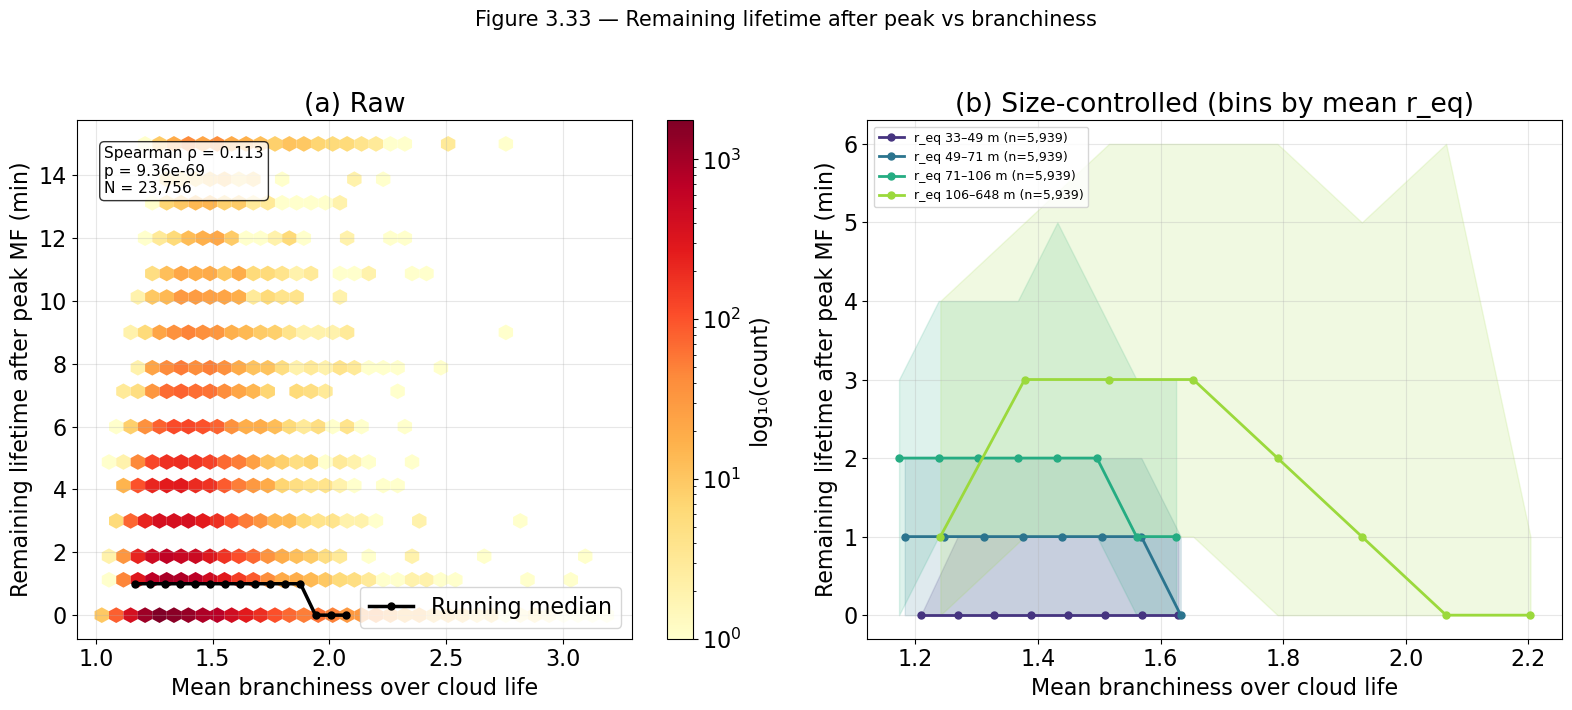


Size-controlled Spearman ρ (time_after_peak_mf vs mean_B)
  33–49 m: ρ = +0.035  (p = 6.402e-03, n = 5,939)
  49–71 m: ρ = -0.006  (p = 6.377e-01, n = 5,939)
  71–106 m: ρ = +0.028  (p = 3.370e-02, n = 5,939)
  106–648 m: ρ = +0.014  (p = 2.680e-01, n = 5,939)

INTERPRETATION:
  Positive ρ → branchier clouds survive LONGER after peak (more vigorous).
  Negative ρ → branchier clouds die FASTER (entrainment erosion).
  ρ ≈ 0 within bins → branchiness has no independent effect on decay.


In [6]:
"""
Figure 3.33 — Remaining lifetime after peak vs branchiness.

Panel (a): Hexbin of time_after_peak_mf (y) vs mean branchiness (x).
Panel (b): Size-controlled — median remaining life vs mean B within size bins.

Uses ALL clouds with a valid peak mass flux (no exponential fit needed).
"""

# ── Subset: clouds with valid remaining-lifetime metric ────────────────────
DECAY_COL = 'time_after_peak_mf'
DECAY_LABEL = 'Remaining lifetime after peak MF (min)'

df_decay = df_section.dropna(subset=[DECAY_COL]).copy()
# Exclude clouds where peak MF is at the very last timestep (0 remaining)
# — these have trivial zero remaining life
df_decay = df_decay[df_decay[DECAY_COL] >= 0].copy()
print(f"Clouds with valid {DECAY_COL}: {len(df_decay):,} / {len(df_section):,} "
      f"({100*len(df_decay)/len(df_section):.1f}%)")

# Display cap for visualisation
DISPLAY_CAP = df_decay[DECAY_COL].quantile(0.99)
print(f"Display cap (99th pctl): {DISPLAY_CAP:.1f} min")

# ── Panel (a): Raw hexbin ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
x = df_decay['mean_B'].values
y = np.clip(df_decay[DECAY_COL].values, None, DISPLAY_CAP)

hb = ax.hexbin(x, y, gridsize=35, cmap='YlOrRd', mincnt=1,
               norm=LogNorm(), edgecolors='none')
plt.colorbar(hb, ax=ax, label='log₁₀(count)')

# Running median
n_bins_median = 15
B_edges = np.linspace(np.nanpercentile(x, 1), np.nanpercentile(x, 99), n_bins_median + 1)
B_centres = 0.5 * (B_edges[:-1] + B_edges[1:])
bin_idx = np.digitize(x, B_edges) - 1

medians = np.full(n_bins_median, np.nan)
for b in range(n_bins_median):
    mask = bin_idx == b
    if mask.sum() >= 5:
        medians[b] = np.nanmedian(y[mask])

valid_med = np.isfinite(medians)
ax.plot(B_centres[valid_med], medians[valid_med], 'k-o', lw=2.5, ms=5,
        label='Running median', zorder=10)

# Spearman (on uncapped values)
rho, p_sp = spearmanr(df_decay['mean_B'], df_decay[DECAY_COL])
ax.text(0.05, 0.95, f'Spearman ρ = {rho:.3f}\np = {p_sp:.2e}\nN = {len(df_decay):,}',
        transform=ax.transAxes, fontsize=11, va='top',
        bbox=dict(boxstyle='round', fc='white', alpha=0.8))

ax.set_xlabel('Mean branchiness over cloud life')
ax.set_ylabel(DECAY_LABEL)
ax.set_title('(a) Raw')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

# ── Panel (b): Size-controlled ────────────────────────────────────────────
ax = axes[1]

r_eq_col = df_decay['mean_r_eq']
quartiles = r_eq_col.quantile([0, 0.25, 0.5, 0.75, 1.0]).values

bin_labels = []
bin_edges  = []
for q in range(4):
    lo = quartiles[q]
    hi = quartiles[q + 1]
    bin_edges.append((lo, hi))
    bin_labels.append(f'{lo:.0f}–{hi:.0f} m')

size_colors = plt.cm.viridis(np.linspace(0.15, 0.85, 4))
n_branch_bins = 8

for q, ((lo, hi), label, color) in enumerate(zip(bin_edges, bin_labels, size_colors)):
    if q < 3:
        mask = (r_eq_col >= lo) & (r_eq_col < hi)
    else:
        mask = (r_eq_col >= lo) & (r_eq_col <= hi)

    sub = df_decay.loc[mask]
    if len(sub) < 20:
        continue

    B_lo = sub['mean_B'].quantile(0.02)
    B_hi = sub['mean_B'].quantile(0.98)
    edges = np.linspace(B_lo, B_hi, n_branch_bins + 1)
    centres = 0.5 * (edges[:-1] + edges[1:])
    digitized = np.digitize(sub['mean_B'].values, edges) - 1

    meds = np.full(n_branch_bins, np.nan)
    q25s = np.full(n_branch_bins, np.nan)
    q75s = np.full(n_branch_bins, np.nan)

    for b in range(n_branch_bins):
        vals = sub.loc[digitized == b, DECAY_COL].values
        if len(vals) >= 5:
            meds[b] = np.nanmedian(vals)
            q25s[b] = np.nanpercentile(vals, 25)
            q75s[b] = np.nanpercentile(vals, 75)

    ok = np.isfinite(meds)
    if ok.sum() < 2:
        continue

    ax.plot(centres[ok], meds[ok], 'o-', color=color, lw=2, ms=5,
            label=f'r_eq {label} (n={len(sub):,})')
    ax.fill_between(centres[ok], q25s[ok], q75s[ok],
                    color=color, alpha=0.15)

ax.set_xlabel('Mean branchiness over cloud life')
ax.set_ylabel(DECAY_LABEL)
ax.set_title('(b) Size-controlled (bins by mean r_eq)')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)

plt.suptitle('Figure 3.33 — Remaining lifetime after peak vs branchiness',
             fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('analysis_plots/fig_3_33_remaining_life_vs_branchiness.pdf', bbox_inches='tight', dpi=300)
plt.show()

# ── Diagnostics ───────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"Size-controlled Spearman ρ ({DECAY_COL} vs mean_B)")
print("="*60)
for q, ((lo, hi), label) in enumerate(zip(bin_edges, bin_labels)):
    if q < 3:
        mask = (r_eq_col >= lo) & (r_eq_col < hi)
    else:
        mask = (r_eq_col >= lo) & (r_eq_col <= hi)
    sub = df_decay.loc[mask]
    if len(sub) < 10:
        print(f"  {label}: n={len(sub)} — too few")
        continue
    rho_bin, p_bin = spearmanr(sub['mean_B'], sub[DECAY_COL])
    print(f"  {label}: ρ = {rho_bin:+.3f}  (p = {p_bin:.3e}, n = {len(sub):,})")
print()
print("INTERPRETATION:")
print("  Positive ρ → branchier clouds survive LONGER after peak (more vigorous).")
print("  Negative ρ → branchier clouds die FASTER (entrainment erosion).")
print("  ρ ≈ 0 within bins → branchiness has no independent effect on decay.")

### Top-10% w vs bottom-90%

This comparison repeats the size-controlled analysis after splitting tracks by peak vertical velocity, so the most vigorous clouds can be compared directly with the rest of the population.

Decay metric: postpeak_flux_integral
Top-10% w threshold: 3.03 m/s

Group                                     N   N(dec)    ρ_raw       p_raw    ρ_Q1    ρ_Q2    ρ_Q3    ρ_Q4
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
Bottom 90% w (< 3.03 m/s)             28284    20613   +0.015    2.97e-02  -0.031  -0.006  +0.001  +0.018
Top 10% w (≥ 3.03 m/s)                 3143     3143   -0.008    6.67e-01  -0.026  +0.010  +0.134  -0.138


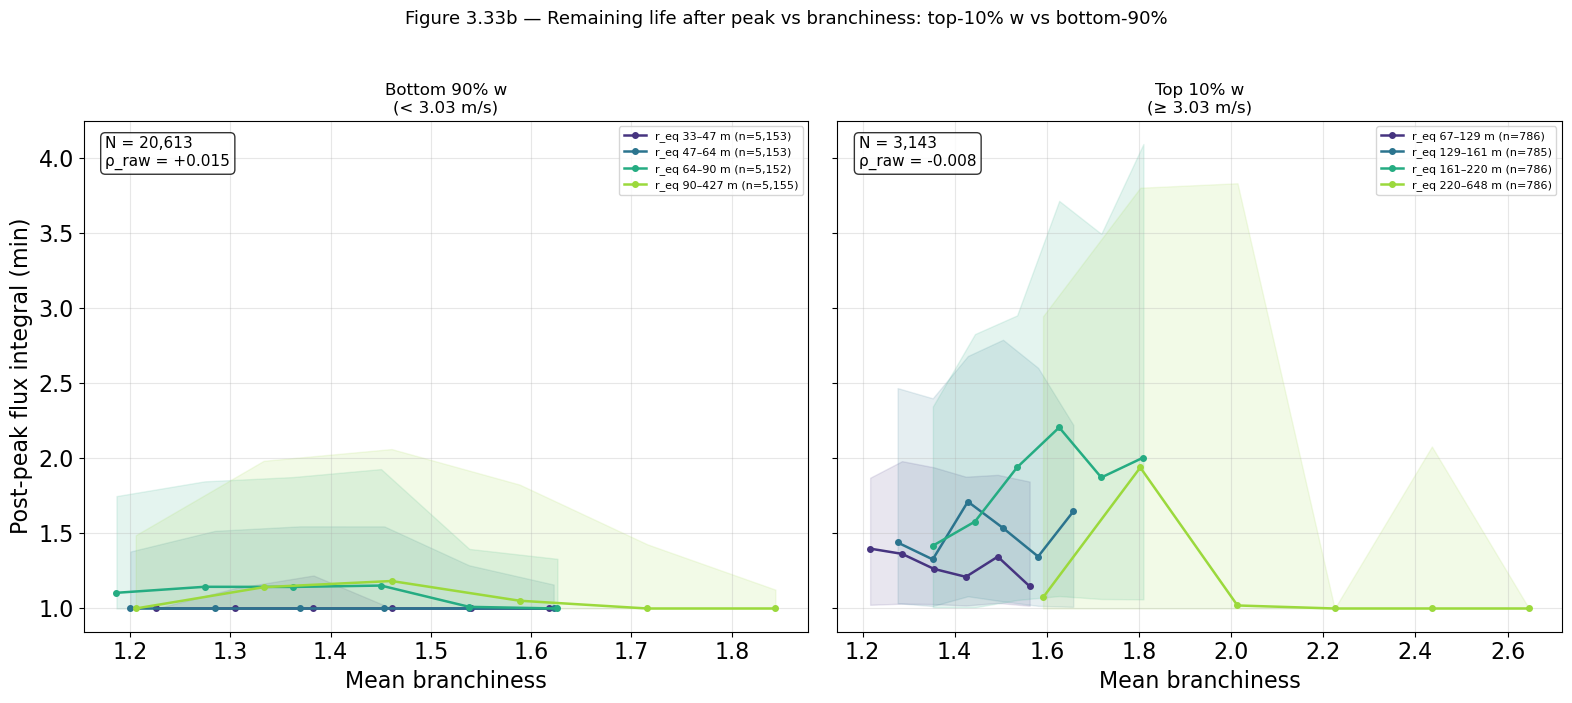


INTERPRETATION
  Positive ρ → branchier clouds survive LONGER after peak (vigour signal).
  Negative ρ → branchier clouds die FASTER (entrainment erosion).
  ρ ≈ 0 within bins → no independent effect.


In [7]:
"""
Figure 3.33b — Top-10% w vs bottom-90%: remaining lifetime after peak vs branchiness.

Uses the continuous post-peak flux integral: I_post = Σ M(t)·Δt / M_peak.
This avoids the integer-valued artefact of time_after_peak_mf (which is
just a count of remaining DT-steps × 1 min).  I_post weights remaining
lifetime by how much flux is still being transported — a slowly-decaying
cloud retains a larger integral than one that drops to zero immediately.

Two panels side-by-side, each size-controlled with 4 r_eq quartile bins.
"""

DECAY_COL   = 'postpeak_flux_integral'
DECAY_LABEL = 'Post-peak flux integral (min)'

# ── Split into top-10% vs bottom-90% ──────────────────────────────────────
w90 = df_section['max_w'].quantile(0.90)

groups = {
    f'Bottom 90% w\n(< {w90:.2f} m/s)': df_section['max_w'] < w90,
    f'Top 10% w\n(≥ {w90:.2f} m/s)':    df_section['max_w'] >= w90,
}

# ── Summary table ──────────────────────────────────────────────────────────
print(f"Decay metric: {DECAY_COL}")
print(f"Top-10% w threshold: {w90:.2f} m/s\n")
print(f"{'Group':<35s}  {'N':>6s}  {'N(dec)':>7s}  {'ρ_raw':>7s}  {'p_raw':>10s}  "
      f"{'ρ_Q1':>6s}  {'ρ_Q2':>6s}  {'ρ_Q3':>6s}  {'ρ_Q4':>6s}")
print("─" * 110)

summary_rows = []

for name, mask in groups.items():
    sub_all = df_section.loc[mask].copy()
    sub = sub_all.dropna(subset=[DECAY_COL]).copy()
    n_all = len(sub_all)
    n_td = len(sub)

    rho_raw, p_raw = spearmanr(sub['mean_B'], sub[DECAY_COL])

    # Size-controlled: 4 quartile bins by mean_r_eq
    r_eq_sub = sub['mean_r_eq']
    qs = r_eq_sub.quantile([0, 0.25, 0.5, 0.75, 1.0]).values
    rho_bins = []
    for q in range(4):
        lo, hi = qs[q], qs[q+1]
        if q < 3:
            m = (r_eq_sub >= lo) & (r_eq_sub < hi)
        else:
            m = (r_eq_sub >= lo) & (r_eq_sub <= hi)
        s = sub.loc[m]
        if len(s) >= 10:
            r, _ = spearmanr(s['mean_B'], s[DECAY_COL])
            rho_bins.append(r)
        else:
            rho_bins.append(np.nan)

    label = name.replace('\n', ' ')
    print(f"{label:<35s}  {n_all:>6d}  {n_td:>7d}  {rho_raw:>+7.3f}  {p_raw:>10.2e}  "
          f"{rho_bins[0]:>+6.3f}  {rho_bins[1]:>+6.3f}  "
          f"{rho_bins[2]:>+6.3f}  {rho_bins[3]:>+6.3f}")
    summary_rows.append(dict(name=name, n_all=n_all, n_td=n_td,
                             rho_raw=rho_raw, p_raw=p_raw,
                             rho_bins=rho_bins))

# ── 1×2 panel plot ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

n_branch_bins = 6
size_colors = plt.cm.viridis(np.linspace(0.15, 0.85, 4))

for idx, (name, mask) in enumerate(groups.items()):
    ax = axes[idx]
    sub = df_section.loc[mask].dropna(subset=[DECAY_COL]).copy()

    r_eq_sub = sub['mean_r_eq']
    qs = r_eq_sub.quantile([0, 0.25, 0.5, 0.75, 1.0]).values
    bin_labels_sub = []
    bin_edges_sub = []
    for q in range(4):
        bin_edges_sub.append((qs[q], qs[q+1]))
        bin_labels_sub.append(f'{qs[q]:.0f}–{qs[q+1]:.0f} m')

    for q, ((lo, hi), lab, color) in enumerate(zip(bin_edges_sub, bin_labels_sub, size_colors)):
        if q < 3:
            m = (r_eq_sub >= lo) & (r_eq_sub < hi)
        else:
            m = (r_eq_sub >= lo) & (r_eq_sub <= hi)
        s = sub.loc[m]
        if len(s) < 10:
            continue

        B_lo = s['mean_B'].quantile(0.02)
        B_hi = s['mean_B'].quantile(0.98)
        edges = np.linspace(B_lo, B_hi, n_branch_bins + 1)
        centres = 0.5 * (edges[:-1] + edges[1:])
        digitized = np.digitize(s['mean_B'].values, edges) - 1

        meds = np.full(n_branch_bins, np.nan)
        q25s = np.full(n_branch_bins, np.nan)
        q75s = np.full(n_branch_bins, np.nan)

        for b in range(n_branch_bins):
            vals = s.loc[digitized == b, DECAY_COL].values
            if len(vals) >= 3:
                meds[b] = np.nanmedian(vals)
                q25s[b] = np.nanpercentile(vals, 25)
                q75s[b] = np.nanpercentile(vals, 75)

        ok = np.isfinite(meds)
        if ok.sum() < 2:
            continue

        ax.plot(centres[ok], meds[ok], 'o-', color=color, lw=1.8, ms=4,
                label=f'r_eq {lab} (n={len(s):,})')
        ax.fill_between(centres[ok], q25s[ok], q75s[ok],
                        color=color, alpha=0.12)

    row = [r for r in summary_rows if r['name'] == name][0]
    rho_str = f"ρ_raw = {row['rho_raw']:+.3f}" if np.isfinite(row['rho_raw']) else "—"
    ax.text(0.03, 0.97, f'N = {row["n_td"]:,}\n{rho_str}',
            transform=ax.transAxes, fontsize=11, va='top',
            bbox=dict(boxstyle='round', fc='white', alpha=0.8))

    ax.set_title(name, fontsize=12)
    ax.set_xlabel('Mean branchiness')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='upper right', ncol=1)

axes[0].set_ylabel(DECAY_LABEL)

plt.suptitle('Figure 3.33b — Remaining life after peak vs branchiness: top-10% w vs bottom-90%',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('analysis_plots/fig_3_33b_top10_vs_bottom90.pdf', bbox_inches='tight', dpi=300)
plt.show()

# ── Interpretation ─────────────────────────────────────────────────────────
print(f"\n{'='*70}")
print("INTERPRETATION")
print("="*70)
print("  Positive ρ → branchier clouds survive LONGER after peak (vigour signal).")
print("  Negative ρ → branchier clouds die FASTER (entrainment erosion).")
print("  ρ ≈ 0 within bins → no independent effect.")

## Branchiness scales with cloud size

This section looks at how branchiness varies with cloud size and how it evolves across normalized lifetime.

- Panel (a): Max branchiness versus max equivalent radius, with reference curves.
- Panel (b): Normalized-lifetime branchiness for fragment and non-fragment track groups.

═══ Geometric null baseline — voxelised sphere on 25 m grid ═══
  Analytic cube branchiness (constant): B_cube = 1.2407
  Large-sphere asymptote: B → 6π/(4π) = 3/2 = 1.500
    (face-counting SA overestimates: each of 6 directions → πR² faces)
  Voxelised sphere range: r_eq = 16 – 1200 m
  B at r_eq ≈ 16 m  (smallest): 1.241
  B at r_eq ≈ 120 m (mid-range):  1.435
  B at r_eq ≈ 1200 m (largest):  1.495

  Cloud median vs voxelised-sphere null at representative sizes:
    r_eq ∈ [ 25,  50) m:  cloud med = 1.34,  null = 1.568,  Δ = -0.23 ↓  (N = 8,145)
    r_eq ∈ [ 50, 100) m:  cloud med = 1.38,  null = 1.511,  Δ = -0.13 ↓  (N = 11,637)
    r_eq ∈ [100, 200) m:  cloud med = 1.54,  null = 1.517,  Δ = +0.03 ↑  (N = 8,083)
    r_eq ∈ [200, 400) m:  cloud med = 1.90,  null = 1.515,  Δ = +0.39 ↑  (N = 3,073)
    r_eq ∈ [400, 800) m:  cloud med = 2.41,  null = 1.501,  Δ = +0.90 ↑  (N = 489)

Panel (a) — Branchiness vs equivalent radius:
  Spearman ρ = 0.552,  p = 0.00e+00,  N = 31,427

Panel (b

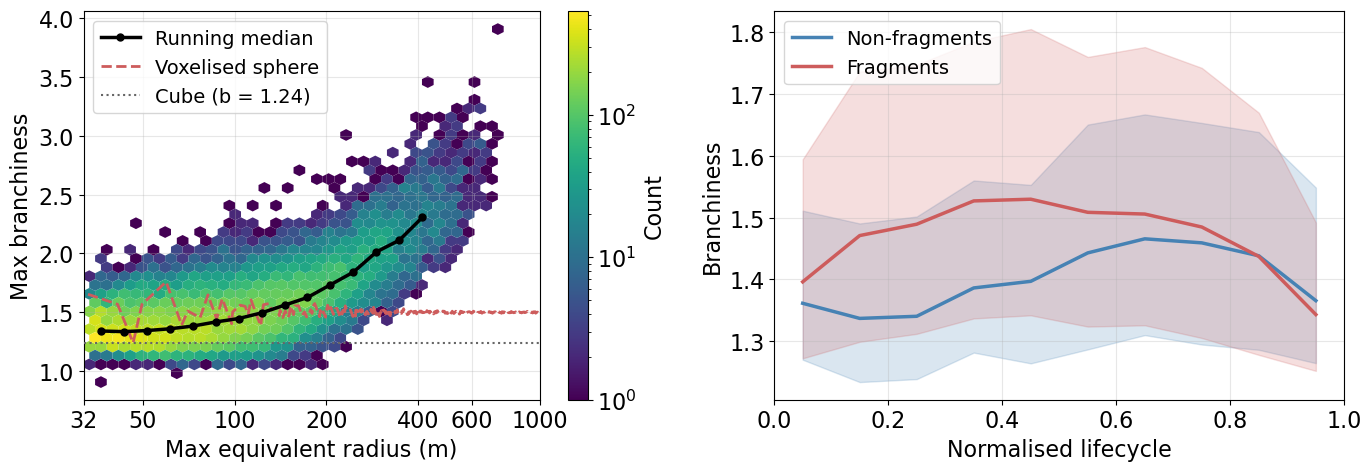

In [ ]:
"""
Figure 3.30 — Branchiness and size.

Panel (a): Hexbin of max branchiness versus max equivalent radius, with
           reference curves.
Panel (b): Normalized-lifecycle branchiness for fragment and
           non-fragment tracks.
"""

# ── Reference curve: branchiness of a voxelised sphere ────────────────────
def _voxelised_sphere_B(r_eq_m, dx=DX):
    """Branchiness for a digital sphere of given r_eq on a dx-grid."""
    r_vox = r_eq_m / dx
    k = int(np.ceil(r_vox)) + 1
    ix = np.arange(-k, k + 1)
    X, Y, Z = np.meshgrid(ix, ix, ix, indexing='ij')
    grid = np.sqrt(X**2 + Y**2 + Z**2) <= r_vox
    N = int(grid.sum())
    if N == 0:
        return np.nan, np.nan
    # Count exposed faces (vectorised shifts)
    exposed = 0
    for axis in range(3):
        for shift in [-1, 1]:
            shifted = np.roll(grid, shift, axis=axis)
            slc = [slice(None)] * 3
            slc[axis] = 0 if shift == 1 else -1
            shifted[tuple(slc)] = False
            exposed += int((grid & ~shifted).sum())
    SA = exposed * dx**2
    V  = N * dx**3
    SA_sph = 4.0 * np.pi * (3.0 * V / (4.0 * np.pi)) ** (2.0 / 3.0)
    return SA / SA_sph, V

# Pre-compute the reference curve over a range of radii
_null_req_input = np.logspace(np.log10(12), np.log10(1200), 1000)
_null_B   = np.full(len(_null_req_input), np.nan)
_null_vol = np.full(len(_null_req_input), np.nan)
for _i, _r in enumerate(_null_req_input):
    _null_B[_i], _null_vol[_i] = _voxelised_sphere_B(_r)

# Actual equivalent radius from the voxel object's volume (not the input radius)
_null_req = (3.0 * _null_vol / (4.0 * np.pi)) ** (1.0 / 3.0)

# Cube reference value (constant across size)
B_CUBE = 6.0 / ((4.0 * np.pi) ** (1.0 / 3.0) * 3.0 ** (2.0 / 3.0))  # ≈ 1.2407

# ── Print reference-curve values ───────────────────────────────────────────
print("═══ Geometric null baseline — voxelised sphere on 25 m grid ═══")
print(f"  Analytic cube branchiness (constant): B_cube = {B_CUBE:.4f}")
print(f"  Large-sphere asymptote: B → 6π/(4π) = 3/2 = 1.500")
print(f"    (face-counting SA overestimates: each of 6 directions → πR² faces)")
print(f"  Voxelised sphere range: r_eq = {_null_req[0]:.0f} – {_null_req[-1]:.0f} m")
print(f"  B at r_eq ≈ {_null_req[0]:.0f} m  (smallest): {_null_B[0]:.3f}")
print(f"  B at r_eq ≈ {_null_req[len(_null_req)//2]:.0f} m (mid-range):  {_null_B[len(_null_B)//2]:.3f}")
print(f"  B at r_eq ≈ {_null_req[-1]:.0f} m (largest):  {_null_B[-1]:.3f}")
print()

# Compare with track medians at representative sizes
print("  Cloud median vs voxelised-sphere null at representative sizes:")
_med_data = df_section.loc[
    (df_section['max_r_eq'] > 0) & np.isfinite(df_section['max_B'])]
for _rbin_lo, _rbin_hi in [(12, 25), (25, 50), (50, 100), (100, 200), (200, 400), (400, 800)]:
    _in_bin = _med_data[
        (_med_data['max_r_eq'] >= _rbin_lo) & (_med_data['max_r_eq'] < _rbin_hi)]
    if len(_in_bin) > 5:
        _r_mid = np.sqrt(_rbin_lo * _rbin_hi)
        _null_at_r = _voxelised_sphere_B(_r_mid)[0]
        _cloud_med = _in_bin['max_B'].median()
        _sign = "↑" if _cloud_med > _null_at_r else "↓"
        print(f"    r_eq ∈ [{_rbin_lo:>3d}, {_rbin_hi:>3d}) m:  "
              f"cloud med = {_cloud_med:.2f},  "
              f"null = {_null_at_r:.3f},  "
              f"Δ = {_cloud_med - _null_at_r:+.2f} {_sign}  "
              f"(N = {len(_in_bin):,})")
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Helper: hexbin scatter with running median ────────────────────────────
def _hexbin_with_median(ax, x, y, xlabel, n_med=15, gridsize=35):
    x_log = np.log10(x)
    hb = ax.hexbin(x_log, y, gridsize=gridsize, cmap='viridis', mincnt=1,
                   norm=LogNorm(), edgecolors='none')
    plt.colorbar(hb, ax=ax, label='Count')

    # Running median
    x_edges = np.linspace(np.nanpercentile(x_log, 1),
                          np.nanpercentile(x_log, 99), n_med + 1)
    x_centres = 0.5 * (x_edges[:-1] + x_edges[1:])
    bins = np.digitize(x_log, x_edges) - 1
    meds = np.full(n_med, np.nan)
    for b in range(n_med):
        vals = y[bins == b]
        if len(vals) >= 5:
            meds[b] = np.nanmedian(vals)
    ok = np.isfinite(meds)
    ax.plot(x_centres[ok], meds[ok], 'k-o', lw=2.5, ms=5,
            label='Running median', zorder=10)

    ax.set_xlabel(xlabel)
    ax.set_ylabel('Max branchiness')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

    # Print statistics instead of annotating on graph
    rho, p_sp = spearmanr(x, y)
    print(f"  Spearman ρ = {rho:.3f},  p = {p_sp:.2e},  N = {len(x):,}")
    return ax

# ── Panel (a): vs equivalent radius ──────────────────────────────────────
plot_mask = (df_section['max_r_eq'] > 0) & np.isfinite(df_section['max_B'])
x_r = df_section.loc[plot_mask, 'max_r_eq'].values
y_r = df_section.loc[plot_mask, 'max_B'].values

print("Panel (a) — Branchiness vs equivalent radius:")
ax = _hexbin_with_median(axes[0], x_r, y_r,
                         'Max equivalent radius (m)')
# X limits and tick labels
ax.set_xlim(np.log10(32), np.log10(1000))
xtv = [32, 50, 100, 200, 400, 600, 1000]
ax.set_xticks([np.log10(v) for v in xtv])
ax.set_xticklabels([str(v) for v in xtv])

# Reference-curve overlay
ax.plot(np.log10(_null_req), _null_B, '--', color='indianred', lw=2.0,
        label='Voxelised sphere', zorder=9)
ax.axhline(B_CUBE, color='0.4', ls=':', lw=1.5,
           label=f'Cube (b = {B_CUBE:.2f})', zorder=9)
ax.legend(loc='upper left', fontsize=14)

# ── Panel (b): Normalised lifecycle branchiness ───────────────────────────
ax = axes[1]

MIN_LIFE_FOR_NORM = 3
N_NORM_BINS       = 10

norm_edges = np.linspace(0, 1, N_NORM_BINS + 1)
norm_centres = 0.5 * (norm_edges[:-1] + norm_edges[1:])

def compute_lifecycle_branchiness(df, raw_data, label, min_life=MIN_LIFE_FOR_NORM):
    all_bins = {b: [] for b in range(N_NORM_BINS)}
    for _, row in df.iterrows():
        i = int(row['track_index'])
        size_row = raw_data['size'][i]
        active_idx = np.where(np.isfinite(size_row) & (size_row > 0))[0]
        if len(active_idx) < min_life:
            continue
        sa  = raw_data['surface_area'][i, active_idx]
        vol = size_row[active_idx] * VOXEL_VOL
        sph = 4.0 * np.pi * (3.0 * vol / (4.0 * np.pi)) ** (2.0 / 3.0)
        with np.errstate(divide='ignore', invalid='ignore'):
            B = np.where(sph > 0, sa / sph, np.nan)
        t0 = active_idx[0]
        t1 = active_idx[-1]
        if t1 == t0:
            continue
        t_norm = (active_idx - t0) / (t1 - t0)
        digit = np.clip(np.digitize(t_norm, norm_edges) - 1, 0, N_NORM_BINS - 1)
        for j, b_val in zip(digit, B):
            if np.isfinite(b_val):
                all_bins[j].append(b_val)
    med = np.full(N_NORM_BINS, np.nan)
    q25 = np.full(N_NORM_BINS, np.nan)
    q75 = np.full(N_NORM_BINS, np.nan)
    for b in range(N_NORM_BINS):
        if len(all_bins[b]) >= 5:
            med[b] = np.nanmedian(all_bins[b])
            q25[b] = np.nanpercentile(all_bins[b], 25)
            q75[b] = np.nanpercentile(all_bins[b], 75)
    return med, q25, q75

MIN_REQ_FIG30 = 150  # metres — restrict panel (b) to large clouds
df_large_fig30 = df_section[df_section['max_r_eq'] > MIN_REQ_FIG30]
df_large_fig30_nf = df_large_fig30[~df_large_fig30['is_fragment'].astype(bool)]
df_large_fig30_fr = df_large_fig30[df_large_fig30['is_fragment'].astype(bool)]
print(f"\nPanel (b) — r_eq > {MIN_REQ_FIG30} m: "
      f"{len(df_large_fig30):,} clouds "
      f"({len(df_large_fig30_nf):,} non-fragments, {len(df_large_fig30_fr):,} fragments)")

med_nf, q25_nf, q75_nf = compute_lifecycle_branchiness(df_large_fig30_nf, raw, 'non-fragment')
med_fr, q25_fr, q75_fr = compute_lifecycle_branchiness(df_large_fig30_fr, raw, 'fragment')

ok_nf = np.isfinite(med_nf)
ok_fr = np.isfinite(med_fr)

ax.plot(norm_centres[ok_nf], med_nf[ok_nf], '-', color='steelblue', lw=2.5,
        label='Non-fragments')
ax.fill_between(norm_centres[ok_nf], q25_nf[ok_nf], q75_nf[ok_nf],
                color='steelblue', alpha=0.2)
ax.plot(norm_centres[ok_fr], med_fr[ok_fr], '-', color='indianred', lw=2.5,
        label='Fragments')
ax.fill_between(norm_centres[ok_fr], q25_fr[ok_fr], q75_fr[ok_fr],
                color='indianred', alpha=0.2)

ax.set_xlabel('Normalised lifecycle')
ax.set_ylabel('Branchiness')
ax.legend(loc='upper left', fontsize=14)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig('analysis_plots/fig_3_30_branchiness_vs_size.pdf', bbox_inches='tight', dpi=300)
plt.show()

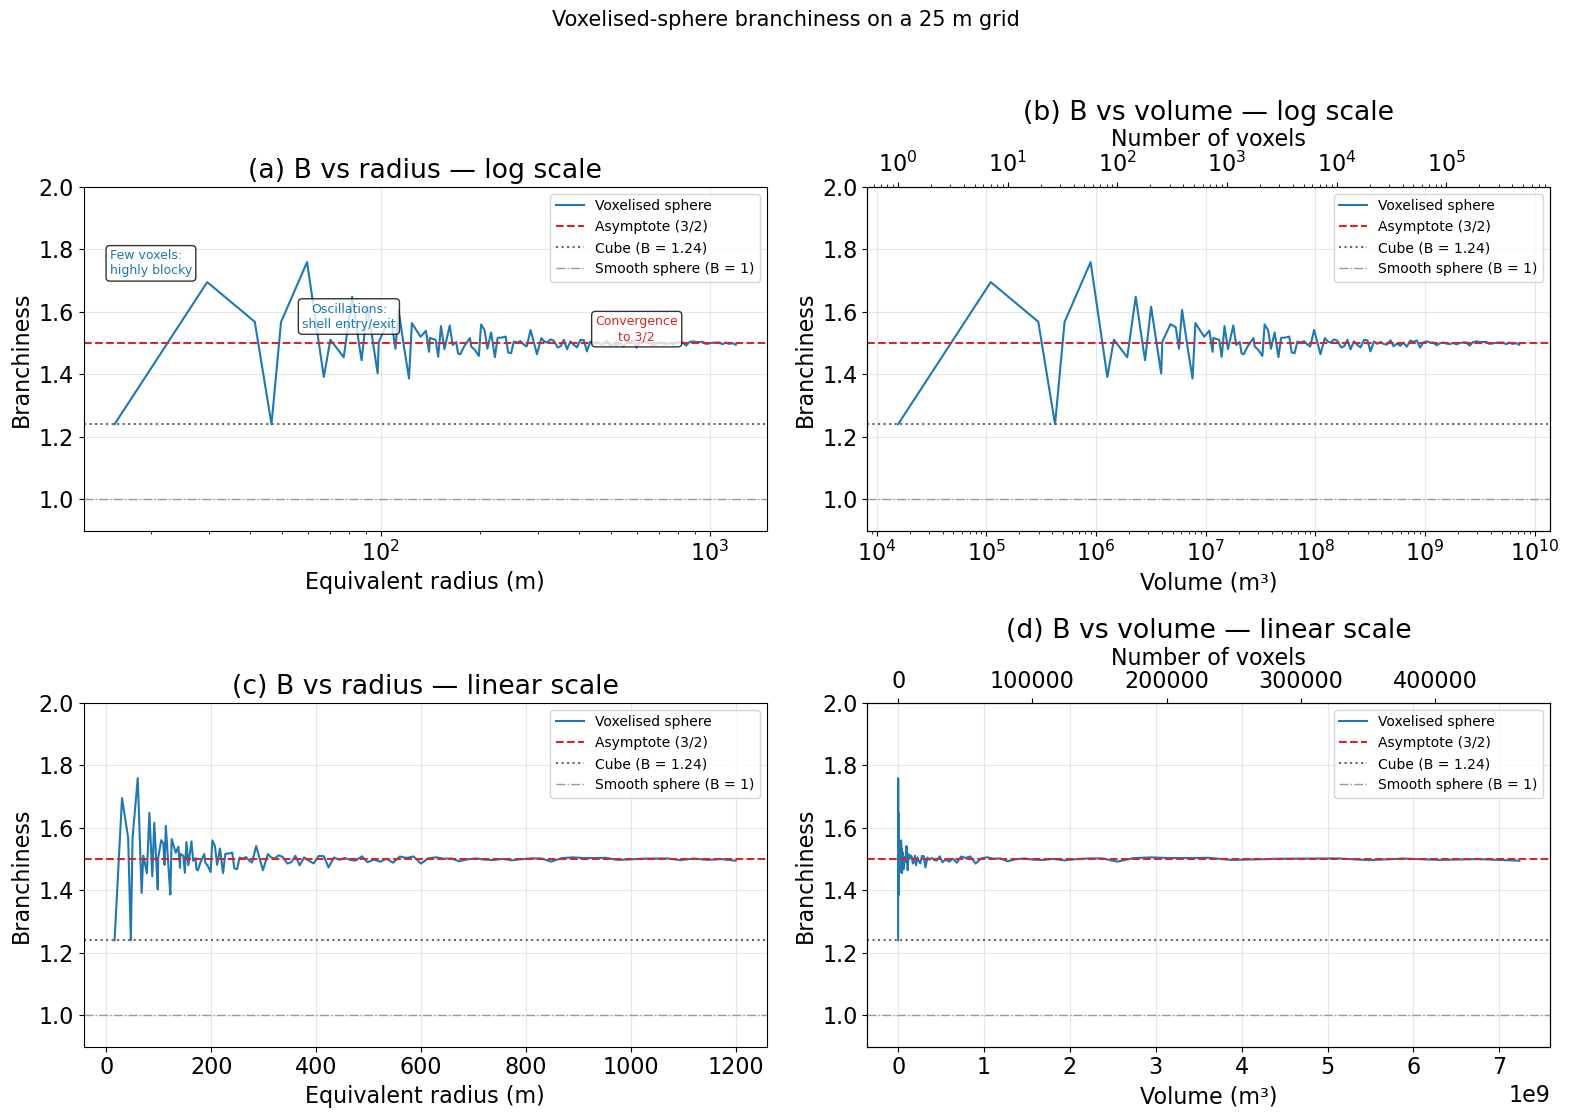


Voxelised sphere at selected radii (actual r_eq from voxel volume):


NameError: name '_r_target' is not defined

In [9]:
"""
Voxelised-sphere baseline — isolated view.

Recomputes the null curve at high resolution (200 radii) so the
oscillation structure is clearly visible.

Row 1: log-scale x-axes   Row 2: linear x-axes
"""

# ── Dense sampling of the voxelised sphere ────────────────────────────────
_dense_req_input = np.logspace(np.log10(12), np.log10(1200), 200)
_dense_B   = np.full(len(_dense_req_input), np.nan)
_dense_vol = np.full(len(_dense_req_input), np.nan)
_dense_N   = np.full(len(_dense_req_input), np.nan)

for _i, _r in enumerate(_dense_req_input):
    _b, _v = _voxelised_sphere_B(_r)
    _dense_B[_i]   = _b
    _dense_vol[_i] = _v
    _dense_N[_i]   = _v / VOXEL_VOL  # number of voxels

# Actual equivalent radius from the voxel object's volume (not the input radius)
_dense_req = (3.0 * _dense_vol / (4.0 * np.pi)) ** (1.0 / 3.0)
_ok = np.isfinite(_dense_vol) & (_dense_vol > 0)

# ── Plot: 2×2 grid ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# --- Shared helper to draw reference lines & labels ----------------------
def _decorate(ax):
    ax.axhline(1.5, color='C3', ls='--', lw=1.5, label='Asymptote (3/2)')
    ax.axhline(B_CUBE, color='0.4', ls=':', lw=1.5, label=f'Cube (B = {B_CUBE:.2f})')
    ax.axhline(1.0, color='0.6', ls='-.', lw=1, label='Smooth sphere (B = 1)')
    ax.set_ylabel('Branchiness')
    ax.set_ylim(0.9, 2.0)
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3)

# ── Row 1: log-scale x-axes ──────────────────────────────────────────────
# (a) B vs radius (log)
ax = axes[0, 0]
ax.plot(_dense_req, _dense_B, 'C0-', lw=1.5, label='Voxelised sphere')
ax.set_xscale('log')
ax.set_xlabel('Equivalent radius (m)')
ax.set_title('(a) B vs radius — log scale')
_decorate(ax)
ax.annotate('Few voxels:\nhighly blocky',
            xy=(15, 1.72), fontsize=9, ha='left', color='C0',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))
ax.annotate('Oscillations:\nshell entry/exit',
            xy=(80, 1.55), fontsize=9, ha='center', color='C0',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))
ax.annotate('Convergence\nto 3/2',
            xy=(600, 1.50), fontsize=9, ha='center', va='bottom', color='C3',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

# (b) B vs volume (log)
ax = axes[0, 1]
ax.plot(_dense_vol[_ok], _dense_B[_ok], 'C0-', lw=1.5, label='Voxelised sphere')
ax.set_xscale('log')
ax.set_xlabel('Volume (m³)')
ax.set_title('(b) B vs volume — log scale')
_decorate(ax)
ax2 = ax.twiny()
ax2.set_xscale('log')
ax2.set_xlim(np.array(ax.get_xlim()) / VOXEL_VOL)
ax2.set_xlabel('Number of voxels')

# ── Row 2: linear x-axes ─────────────────────────────────────────────────
# (c) B vs radius (linear)
ax = axes[1, 0]
ax.plot(_dense_req, _dense_B, 'C0-', lw=1.5, label='Voxelised sphere')
ax.set_xlabel('Equivalent radius (m)')
ax.set_title('(c) B vs radius — linear scale')
_decorate(ax)

# (d) B vs volume (linear)
ax = axes[1, 1]
ax.plot(_dense_vol[_ok], _dense_B[_ok], 'C0-', lw=1.5, label='Voxelised sphere')
ax.set_xlabel('Volume (m³)')
ax.set_title('(d) B vs volume — linear scale')
_decorate(ax)
ax2 = ax.twiny()
ax2.set_xlim(np.array(ax.get_xlim()) / VOXEL_VOL)
ax2.set_xlabel('Number of voxels')

plt.suptitle('Voxelised-sphere branchiness on a 25 m grid', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('analysis_plots/fig_voxelised_sphere_baseline.pdf', bbox_inches='tight', dpi=300)
plt.show()
print(f"\nVoxelised sphere at selected radii (actual r_eq from voxel volume):")
# ── Print key values ──────────────────────────────────────────────────────
_idx = np.argmin(np.abs(_dense_req_input - _r_target))
print(f"  input r = {_dense_req_input[_idx]:>7.1f} m  →  "
        f"actual r_eq = {_dense_req[_idx]:>7.1f} m  "

        f"({_dense_N[_idx]:>10,.0f} voxels)  →  B = {_dense_B[_idx]:.4f}")
print(f"  r_eq = {_dense_req[_idx]:>7.1f} m  "          f"({_dense_N[_idx]:>10,.0f} voxels)  →  B = {_dense_B[_idx]:.4f}")

## Branchiness and vigour are contemporaneous

This section compares branchiness with peak vertical velocity and then examines how branchiness behaves around the time of peak updraft.

- Panel (a): Max branchiness versus max $w$.
- Panel (b): Top-10% $w$ tracks at {-3 min, peak $w$, +3 min}.
- Panel (c): Bottom-90% $w$ tracks at the same offsets.

Panel (a) — Pearson R² = 0.2593, Spearman ρ = 0.4586, N = 6,279
Top-10% w threshold: 3.03 m/s  (top 10%: 3,143, bottom 90%: 28,284)
Top-10% w, ±3 min: 1074 paired clouds
Bottom-90% w, ±3 min: 1352 paired clouds


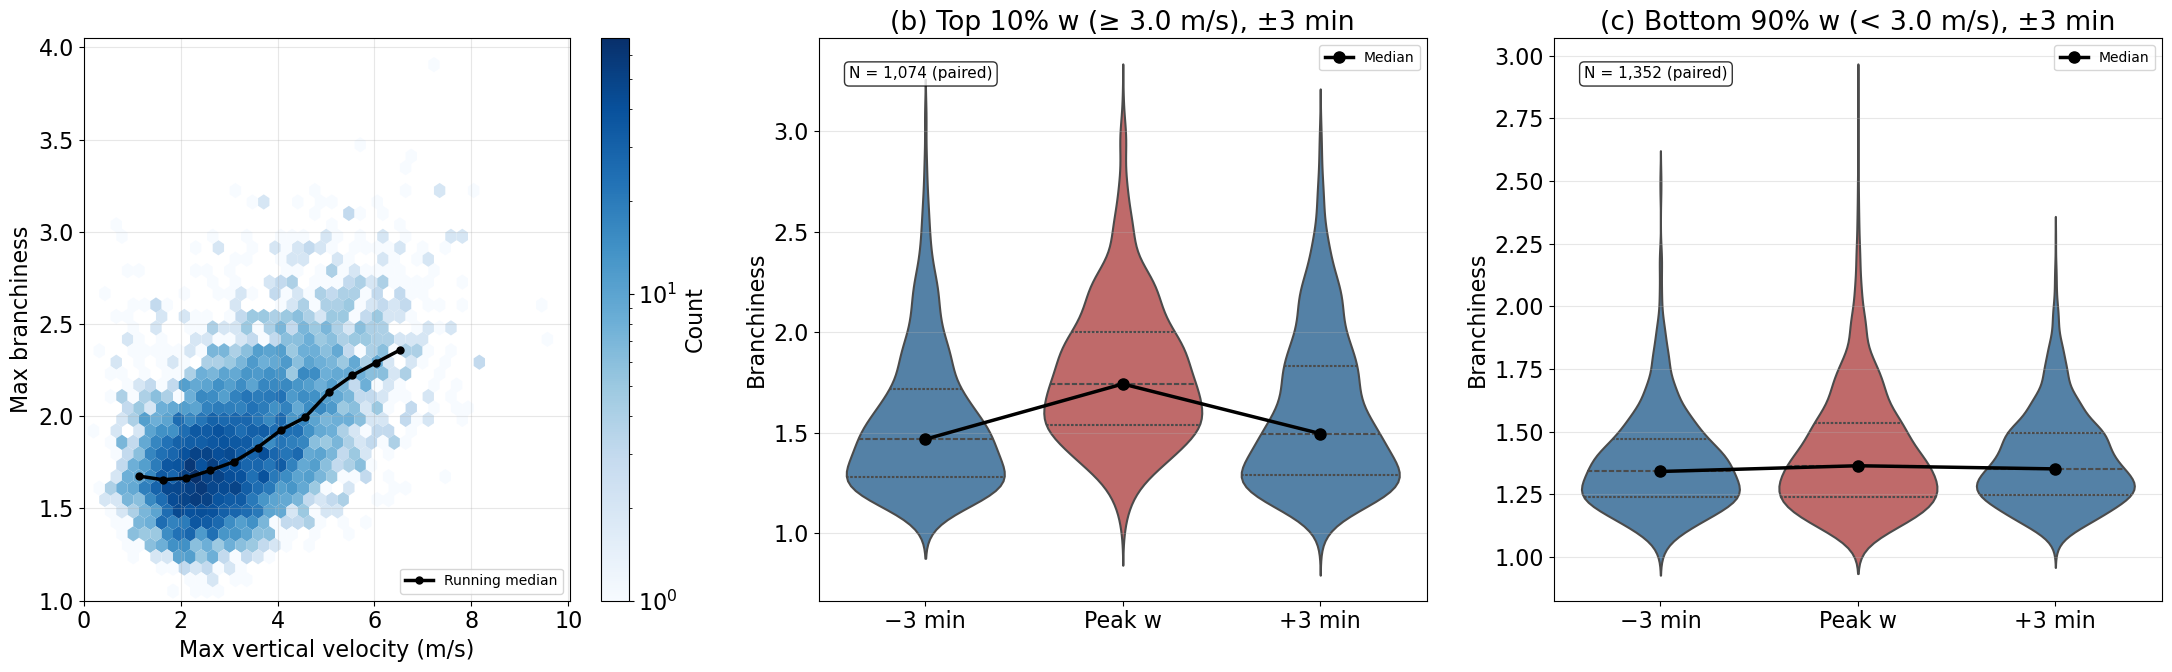



Panel (b) Top-10%, paired ±3 min (1074 clouds):
  Before  : median = 1.468,  mean = 1.551
  Peak    : median = 1.743,  mean = 1.797
  After   : median = 1.496,  mean = 1.597
  Δ(peak − before) = +0.2745
  Wilcoxon: Before→Peak p=1.9507e-86, Peak→After p=4.6313e-44, Before→After p=5.6773e-04

Panel (c) Bottom-90%, paired ±3 min (1352 clouds):
  Before  : median = 1.341,  mean = 1.376
  Peak    : median = 1.364,  mean = 1.415
  After   : median = 1.351,  mean = 1.388
  Δ(peak − before) = +0.0229
  Wilcoxon: Before→Peak p=2.3224e-06, Peak→After p=9.1271e-02, Before→After p=4.9365e-02


In [10]:
"""
Figure 3.31 — Branchiness and vigour are contemporaneous.

Panel (a): Hexbin of max branchiness (y) vs max w (x), with running median.
Panel (b): Top-10% w violin at ±3 min (paired).
Panel (c): Bottom-90% w violin at ±3 min (paired).
"""

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# ── Panel (a): Hexbin of max branchiness vs max w (r_eq > 150 m) ──────────
ax = axes[0]

df_a = df_section[df_section['max_r_eq'] > 150]
mask_a = np.isfinite(df_a['max_w']) & (df_a['max_w'] > 0) & np.isfinite(df_a['max_B'])
x_a = df_a.loc[mask_a, 'max_w'].values
y_a = df_a.loc[mask_a, 'max_B'].values

hb = ax.hexbin(x_a, y_a, gridsize=40, cmap='Blues', mincnt=1,
               norm=LogNorm(), edgecolors='none')
plt.colorbar(hb, ax=ax, label='Count')

n_wbins = 12
w_edges = np.linspace(np.nanpercentile(x_a, 1), np.nanpercentile(x_a, 99), n_wbins + 1)
w_centres = 0.5 * (w_edges[:-1] + w_edges[1:])
bins_w = np.digitize(x_a, w_edges) - 1

med_w = np.full(n_wbins, np.nan)
for b in range(n_wbins):
    vals = y_a[bins_w == b]
    if len(vals) >= 5:
        med_w[b] = np.nanmedian(vals)

ok = np.isfinite(med_w)
ax.plot(w_centres[ok], med_w[ok], 'k-o', lw=2.5, ms=5, zorder=10,
        label='Running median')

ax.set_xlabel('Max vertical velocity (m/s)')
ax.set_ylabel('Max branchiness')
ax.set_xlim(left=0)
ax.set_ylim(bottom=1)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

# Print stats
r_val, p_val = pearsonr(x_a, y_a)
r2 = r_val ** 2
rho_sp, p_sp = spearmanr(x_a, y_a)
print(f"Panel (a) — Pearson R² = {r2:.4f}, Spearman ρ = {rho_sp:.4f}, N = {mask_a.sum():,}")

# ── Helper: compute paired branchiness around peak w for a SUBSET ─────────
def compute_violin_data_subset(df_sub, offset_min):
    """Like compute_violin_data but takes a subset DataFrame."""
    recs = []
    for _, row in df_sub.iterrows():
        i = int(row['track_index'])
        mw_row   = raw['max_w'][i, :]
        size_row = raw['size'][i, :]
        sa_row   = raw['surface_area'][i, :]

        active = np.isfinite(size_row) & (size_row > 0)
        active_idx = np.where(active)[0]
        if len(active_idx) < (2 * offset_min + 1):
            continue

        mw_active = mw_row[active_idx]
        pos_w = mw_active > 0
        if not pos_w.any():
            continue
        peak_local = int(np.nanargmax(mw_active))
        peak_t = active_idx[peak_local]

        t_before = peak_t - offset_min
        t_peak   = peak_t
        t_after  = peak_t + offset_min

        if not (0 <= t_before < len(active) and active[t_before]):
            continue
        if not (0 <= t_after < len(active) and active[t_after]):
            continue

        def _branch(t):
            s = size_row[t]
            sa = sa_row[t]
            if s <= 0 or not np.isfinite(sa) or sa <= 0:
                return np.nan
            vol = s * VOXEL_VOL
            sph = 4.0 * np.pi * (3.0 * vol / (4.0 * np.pi)) ** (2.0 / 3.0)
            return sa / sph if sph > 0 else np.nan

        b_before = _branch(t_before)
        b_peak   = _branch(t_peak)
        b_after  = _branch(t_after)

        if all(np.isfinite([b_before, b_peak, b_after])):
            recs.append(dict(before=b_before, peak=b_peak, after=b_after))

    return pd.DataFrame(recs)

# ── Helper: plot a violin panel ───────────────────────────────────────────
from scipy.stats import wilcoxon

def plot_violin_panel(ax, df_v, offset_min, panel_label, title_extra=''):
    df_long = pd.DataFrame({
        'Branchiness': np.concatenate([df_v['before'], df_v['peak'], df_v['after']]),
        'Phase': ([f'−{offset_min} min'] * len(df_v) +
                  ['Peak w'] * len(df_v) +
                  [f'+{offset_min} min'] * len(df_v))
    })
    phase_order = [f'−{offset_min} min', 'Peak w', f'+{offset_min} min']

    sns.violinplot(data=df_long, x='Phase', y='Branchiness',
                   hue='Phase', order=phase_order, hue_order=phase_order,
                   inner='quartile',
                   palette=[('steelblue'), ('indianred'), ('steelblue')],
                   linewidth=1.5, legend=False, ax=ax)

    medians_v = [df_v['before'].median(), df_v['peak'].median(), df_v['after'].median()]
    ax.plot([0, 1, 2], medians_v, 'ko-', lw=2.5, ms=8, zorder=10, label='Median')

    ax.text(0.05, 0.95, f'N = {len(df_v):,} (paired)',
            transform=ax.transAxes, fontsize=11, va='top',
            bbox=dict(boxstyle='round', fc='white', alpha=0.8))

    ax.set_ylabel('Branchiness')
    ax.set_xlabel('')
    ax.set_title(f'{panel_label} {title_extra}')
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    return medians_v

# ── Top-10% / bottom-90% w subsets ───────────────────────────────────────
w90_thresh = df_section['max_w'].quantile(0.90)
df_top10 = df_section.loc[df_section['max_w'] >= w90_thresh].copy()
df_bot90 = df_section.loc[df_section['max_w'] < w90_thresh].copy()
print(f"Top-10% w threshold: {w90_thresh:.2f} m/s  "
      f"(top 10%: {len(df_top10):,}, bottom 90%: {len(df_bot90):,})")

# ── Panel (b): Top-10% w, ±3 minutes ─────────────────────────────────────
df_v3_top10 = compute_violin_data_subset(df_top10, 3)
print(f"Top-10% w, ±3 min: {len(df_v3_top10)} paired clouds")
med_v2 = plot_violin_panel(axes[1], df_v3_top10, 3, '(b)',
                           f'Top 10% w (≥ {w90_thresh:.1f} m/s), ±3 min')

# ── Panel (c): Bottom-90% w, ±3 minutes ──────────────────────────────────
df_v3_bot90 = compute_violin_data_subset(df_bot90, 3)
print(f"Bottom-90% w, ±3 min: {len(df_v3_bot90)} paired clouds")
med_v3 = plot_violin_panel(axes[2], df_v3_bot90, 3, '(c)',
                           f'Bottom 90% w (< {w90_thresh:.1f} m/s), ±3 min')

plt.tight_layout()
plt.savefig('analysis_plots/fig_3_31_branchiness_and_vigour.pdf', bbox_inches='tight', dpi=300)
plt.show()

# ── Statistics ────────────────────────────────────────────────────────────
print(f"\n{'='*60}")
for offset, df_v, label in [(3, df_v3_top10, 'Panel (b) Top-10%'),
                              (3, df_v3_bot90, 'Panel (c) Bottom-90%')]:
    print(f"\n{label}, paired ±{offset} min ({len(df_v)} clouds):")
    print(f"  Before  : median = {df_v['before'].median():.3f},  mean = {df_v['before'].mean():.3f}")
    print(f"  Peak    : median = {df_v['peak'].median():.3f},  mean = {df_v['peak'].mean():.3f}")
    print(f"  After   : median = {df_v['after'].median():.3f},  mean = {df_v['after'].mean():.3f}")
    delta = df_v['peak'].median() - df_v['before'].median()
    print(f"  Δ(peak − before) = {delta:+.4f}")
    if len(df_v) >= 10:
        stat_bp, p_bp = wilcoxon(df_v['peak'] - df_v['before'])
        stat_pa, p_pa = wilcoxon(df_v['after'] - df_v['peak'])
        stat_ba, p_ba = wilcoxon(df_v['after'] - df_v['before'])
        print(f"  Wilcoxon: Before→Peak p={p_bp:.4e}, Peak→After p={p_pa:.4e}, Before→After p={p_ba:.4e}")

r_eq > 150 m: 6,280 clouds, w90 = 4.94 m/s
  Top 10%: 628 → 272 with ±3 min data
  Bot 90%: 5,652 → 1,329 with ±3 min data
Violin panel: Top 10% N=272, Bottom 90% N=1329


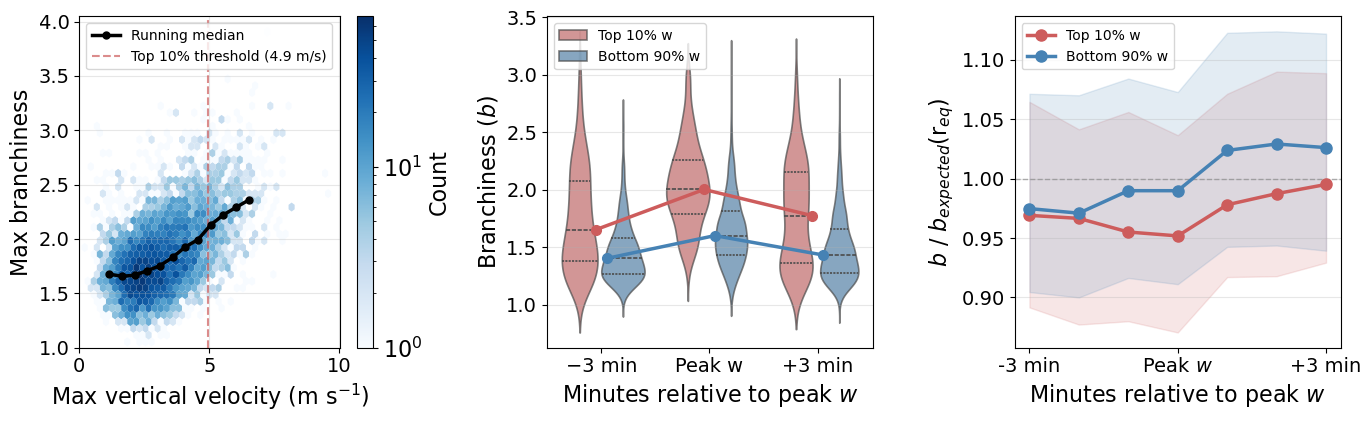


Size-normalised branchiness ±3 min around peak w (r_eq > 150 m)

Top 10% (272 clouds):
   RAW:  t-3=1.6527  t-2=1.7821  t-1=1.8814  t+0=2.0026  t+1=1.8929  t+2=1.8944  t+3=1.7745
        t-3 vs peak: Δmed=-0.2345, p=7.6366e-25 ***
        t-2 vs peak: Δmed=-0.1224, p=8.5546e-18 ***
        t-1 vs peak: Δmed=-0.0651, p=1.0418e-12 ***
        t+1 vs peak: Δmed=+0.0032, p=7.9949e-04 ***
        t+2 vs peak: Δmed=-0.0474, p=4.1219e-06 ***
        t+3 vs peak: Δmed=-0.2043, p=1.7968e-12 ***
  NORM:  t-3=0.9690  t-2=0.9665  t-1=0.9550  t+0=0.9517  t+1=0.9780  t+2=0.9874  t+3=0.9951
        t-3 vs peak: Δmed=+0.0041, p=1.8481e-01 ns
        t-2 vs peak: Δmed=-0.0115, p=8.1670e-01 ns
        t-1 vs peak: Δmed=-0.0058, p=9.9078e-01 ns
        t+1 vs peak: Δmed=+0.0241, p=1.2586e-06 ***
        t+2 vs peak: Δmed=+0.0464, p=1.3267e-07 ***
        t+3 vs peak: Δmed=+0.0615, p=6.5885e-09 ***

Bottom 90% (1329 clouds):
   RAW:  t-3=1.4024  t-2=1.4408  t-1=1.4811  t+0=1.6008  t+1=1.5384  t+2=1.5060 

In [ ]:
"""
Figure 3.31b — Three-panel summary of branchiness around peak updraft.

(a) Hexbin: max B vs max w (r_eq > 150 m) — same as Fig 3.31(a).
(b) Raw branchiness from peak w to +3 min, top 10% vs bottom 90%.
(c) Size-normalised branchiness from peak w to +3 min, top 10% vs bottom 90%.

All clouds: max r_eq > 150 m.
"""

# ── Helper: raw + normalised B at offsets −max_off to +max_off from peak w ─
def compute_symmetric_B(df_sub, max_off):
    """Return DataFrame with raw B and B_norm at t−max_off … t+max_off."""
    recs = []
    offsets_range = list(range(-max_off, max_off + 1))
    for _, row in df_sub.iterrows():
        i = int(row['track_index'])
        mw_row   = raw['max_w'][i, :]
        size_row = raw['size'][i, :]
        sa_row   = raw['surface_area'][i, :]

        active = np.isfinite(size_row) & (size_row > 0)
        active_idx = np.where(active)[0]
        if len(active_idx) < 2 * max_off + 1:
            continue

        mw_active = mw_row[active_idx]
        if not (mw_active > 0).any():
            continue
        peak_t = active_idx[int(np.nanargmax(mw_active))]

        ts = [peak_t + o for o in offsets_range]
        if any(t < 0 or t >= len(active) or not active[t] for t in ts):
            continue

        rec = {}
        all_ok = True
        for o, t in zip(offsets_range, ts):
            s = size_row[t]; sa = sa_row[t]
            if s <= 0 or not np.isfinite(sa) or sa <= 0:
                all_ok = False; break
            vol = s * VOXEL_VOL
            req = (3.0 * vol / (4.0 * np.pi)) ** (1.0 / 3.0)
            sph = 4.0 * np.pi * (3.0 * vol / (4.0 * np.pi)) ** (2.0 / 3.0)
            B_raw = sa / sph if sph > 0 else np.nan
            B_exp = float(B_expected_func(req))
            B_norm = B_raw / B_exp if B_exp > 0 else np.nan
            if not (np.isfinite(B_raw) and np.isfinite(B_norm)):
                all_ok = False; break
            rec[f'raw_{o:+d}'] = B_raw
            rec[f'norm_{o:+d}'] = B_norm
        if all_ok:
            recs.append(rec)
    return pd.DataFrame(recs)

# ── Population: r_eq > 150 m, split by top-10% / bottom-90% w ────────────
df_lg = df_section[df_section['max_r_eq'] > 150].copy()
w90 = df_lg['max_w'].quantile(0.90)
df_top = df_lg[df_lg['max_w'] >= w90]
df_bot = df_lg[df_lg['max_w'] < w90]

df_pp_top = compute_symmetric_B(df_top, 3)
df_pp_bot = compute_symmetric_B(df_bot, 3)
print(f"r_eq > 150 m: {len(df_lg):,} clouds, w90 = {w90:.2f} m/s")
print(f"  Top 10%: {len(df_top):,} → {len(df_pp_top):,} with ±3 min data")
print(f"  Bot 90%: {len(df_bot):,} → {len(df_pp_bot):,} with ±3 min data")

# ── Figure ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# ── Hexbin: max b vs max w ───────────────────────────────────────────────
ax = axes[0]
mask_a = np.isfinite(df_lg['max_w']) & (df_lg['max_w'] > 0) & np.isfinite(df_lg['max_B'])
x_a = df_lg.loc[mask_a, 'max_w'].values
y_a = df_lg.loc[mask_a, 'max_B'].values
hb = ax.hexbin(x_a, y_a, gridsize=40, cmap='Blues', mincnt=1,
               norm=LogNorm(), edgecolors='none')
plt.colorbar(hb, ax=ax, label='Count')

n_wbins = 12
w_edges = np.linspace(np.nanpercentile(x_a, 1), np.nanpercentile(x_a, 99), n_wbins + 1)
w_centres = 0.5 * (w_edges[:-1] + w_edges[1:])
bins_w = np.digitize(x_a, w_edges) - 1
med_w = np.full(n_wbins, np.nan)
for b in range(n_wbins):
    vals = y_a[bins_w == b]
    if len(vals) >= 5:
        med_w[b] = np.nanmedian(vals)
ok = np.isfinite(med_w)
ax.plot(w_centres[ok], med_w[ok], 'k-o', lw=2.5, ms=5, zorder=10, label='Running median')
ax.axvline(w90, color='indianred', ls='--', lw=1.5, alpha=0.7, label=f'Top 10% threshold ({w90:.1f} m/s)')

ax.set_xlabel('Max vertical velocity (m s$^{-1}$)', fontsize=FS)
ax.set_ylabel('Max branchiness', fontsize=FS)
ax.set_xlim(left=0); ax.set_ylim(bottom=1)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=FS - 2)

# ── Paired violins: raw b at −3 / Peak / +3 min, both groups ─────────────
ax = axes[1]
offset_min = 3
df_v_top = compute_violin_data_subset(df_top, offset_min)
df_v_bot = compute_violin_data_subset(df_bot, offset_min)
print(f"Violin panel: Top 10% N={len(df_v_top)}, Bottom 90% N={len(df_v_bot)}")

phase_order = [f'−{offset_min} min', 'Peak w', f'+{offset_min} min']
df_long_b = pd.concat([
    pd.DataFrame({'Branchiness': np.concatenate([df_v_top['before'], df_v_top['peak'], df_v_top['after']]),
                  'Phase': phase_order[0:1]*len(df_v_top) + phase_order[1:2]*len(df_v_top) + phase_order[2:3]*len(df_v_top),
                  'Group': ['Top 10% w']*3*len(df_v_top)}),
    pd.DataFrame({'Branchiness': np.concatenate([df_v_bot['before'], df_v_bot['peak'], df_v_bot['after']]),
                  'Phase': phase_order[0:1]*len(df_v_bot) + phase_order[1:2]*len(df_v_bot) + phase_order[2:3]*len(df_v_bot),
                  'Group': ['Bottom 90% w']*3*len(df_v_bot)})
])

group_order = ['Top 10% w', 'Bottom 90% w']
sns.violinplot(data=df_long_b, x='Phase', y='Branchiness', hue='Group',
               order=phase_order, hue_order=group_order,
               split=False, inner='quartile', linewidth=1.2,
               palette=['indianred', 'steelblue'], alpha=0.7, ax=ax)

# Overlay median lines per group
for df_v, color, dx in [(df_v_top, 'indianred', -0.05), (df_v_bot, 'steelblue', 0.05)]:
    meds = [df_v['before'].median(), df_v['peak'].median(), df_v['after'].median()]
    ax.plot(np.arange(3) + dx, meds, 'o-', color=color, lw=2.5, ms=7, zorder=10)

ax.set_xlabel('Minutes relative to peak $w$', fontsize=FS)
ax.set_ylabel('Branchiness ($b$)', fontsize=FS)
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
ax.tick_params(labelsize=FS - 2)

# ── Size-normalised branchiness: −3 to +3 min ────────────────────────────
ax = axes[2]
sym_offsets = list(range(-3, 4))
x_sym = np.array(sym_offsets, dtype=float)

for df_pp, label, color in [(df_pp_top, 'Top 10% w', 'indianred'),
                              (df_pp_bot, 'Bottom 90% w', 'steelblue')]:
    cols = [f'norm_{o:+d}' for o in sym_offsets]
    meds = [df_pp[c].median() for c in cols]
    q25  = [df_pp[c].quantile(0.25) for c in cols]
    q75  = [df_pp[c].quantile(0.75) for c in cols]
    ax.fill_between(x_sym, q25, q75, alpha=0.15, color=color)
    ax.plot(x_sym, meds, 'o-', color=color, lw=2.5, ms=8, label=label, zorder=5)

ax.axhline(1.0, color='grey', ls='--', lw=1.0, alpha=0.6)
ax.set_xticks([-3, 0, 3]); ax.set_xticklabels(['-3 min', 'Peak $w$', '+3 min'])
ax.set_xlabel('Minutes relative to peak $w$', fontsize=FS)
ax.set_ylabel(r'$b$ / $b_{expected}$(r$_{eq}$)', fontsize=FS)
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
ax.tick_params(labelsize=FS - 2)

plt.tight_layout()
plt.savefig('analysis_plots/fig_3_31b_branchiness_evolution.pdf', bbox_inches='tight', dpi=300)
plt.show()

# ── Statistics ────────────────────────────────────────────────────────────
print(f"\n{'='*70}")
print(f"Size-normalised branchiness ±3 min around peak w (r_eq > 150 m)")
print(f"{'='*70}")
sig = lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
for df_pp, grp in [(df_pp_top, 'Top 10%'), (df_pp_bot, 'Bottom 90%')]:
    print(f"\n{grp} ({len(df_pp)} clouds):")
    for kind, kind_label in [('raw', 'RAW'), ('norm', 'NORM')]:
        cols = [f'{kind}_{o:+d}' for o in sym_offsets]
        print(f"  {kind_label:>4s}:  " + "  ".join(f"t{o:+d}={df_pp[c].median():.4f}" for o, c in zip(sym_offsets, cols)))
        peak_col = f'{kind}_{0:+d}'
        for o in sym_offsets:
            if o == 0:
                continue
            test_col = f'{kind}_{o:+d}'
            diff = df_pp[test_col] - df_pp[peak_col]
            _, p = wilcoxon(diff)
            print(f"        t{o:+d} vs peak: Δmed={diff.median():+.4f}, p={p:.4e} {sig(p)}")

B_expected lookup built from 122,719 (r_eq, B) pairs
  r_eq range: [37, 506] m
Clouds with max r_eq > 150 m: 6,280
  Q1 (0–20%): w ∈ [-0.04, 2.10) m/s — 1,256 clouds, 141 with ±3 min data
  Q2 (20–40%): w ∈ [2.10, 2.67) m/s — 1,256 clouds, 243 with ±3 min data
  Q3 (40–60%): w ∈ [2.67, 3.31) m/s — 1,256 clouds, 305 with ±3 min data
  Q4 (60–80%): w ∈ [3.31, 4.18) m/s — 1,256 clouds, 402 with ±3 min data
  Q5 (80–100%): w ∈ [4.18, 9.57) m/s — 1,256 clouds, 510 with ±3 min data


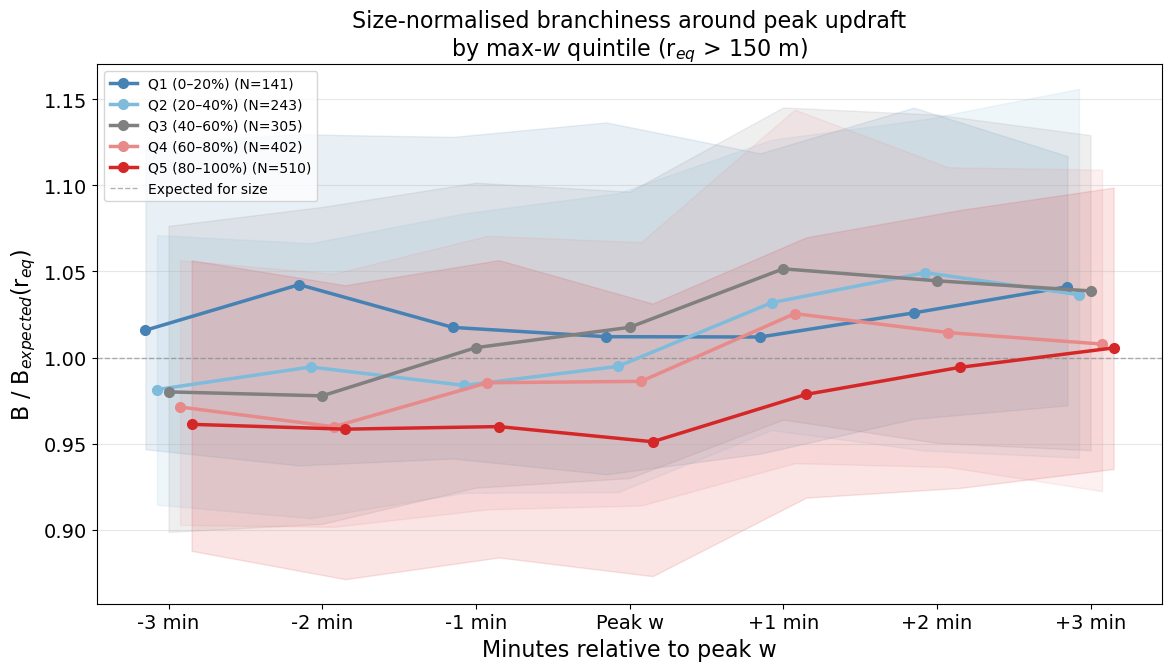


SIZE-NORMALISED branchiness around peak w  (r_eq > 150 m)

Q1 (0–20%) (141 clouds, w ∈ [-0.04, 2.10]):
    offset    median
    -3 min     1.0159
    -2 min     1.0424
    -1 min     1.0175
    +0 min     1.0121
    +1 min     1.0119
    +2 min     1.0259
    +3 min     1.0412
  Wilcoxon vs peak (t+0):
    t-3 → peak: Δmed=-0.0038, p=2.7856e-01 ns
    t-2 → peak: Δmed=-0.0303, p=3.1770e-01 ns
    t-1 → peak: Δmed=-0.0054, p=5.0818e-01 ns
    t+1 → peak: Δmed=+0.0002, p=2.6597e-01 ns
    t+2 → peak: Δmed=-0.0138, p=5.6016e-02 ns
    t+3 → peak: Δmed=-0.0291, p=8.1482e-02 ns

Q2 (20–40%) (243 clouds, w ∈ [2.10, 2.67]):
    offset    median
    -3 min     0.9814
    -2 min     0.9945
    -1 min     0.9838
    +0 min     0.9949
    +1 min     1.0319
    +2 min     1.0493
    +3 min     1.0365
  Wilcoxon vs peak (t+0):
    t-3 → peak: Δmed=+0.0135, p=6.9220e-02 ns
    t-2 → peak: Δmed=+0.0004, p=2.3536e-02 *
    t-1 → peak: Δmed=+0.0111, p=3.0861e-02 *
    t+1 → peak: Δmed=-0.0370, p=2.050

In [ ]:
"""
Size-normalised branchiness around peak w.

B_norm(t) = B(t) / B_expected(r_eq(t)), where B_expected is the
running-median branchiness at a given equivalent radius across all
active timesteps.

This cell builds the size-normalised time window used to compare raw
and normalised branchiness around peak updraft.
"""
from scipy.interpolate import interp1d

# ── Build B_expected(r_eq) lookup from the full population ────────────────
_all_req = []
_all_B   = []

for _, row in df_section.iterrows():
    i = int(row['track_index'])
    size_row = raw['size'][i, :]
    sa_row   = raw['surface_area'][i, :]
    active   = np.isfinite(size_row) & (size_row > 0)
    active_idx = np.where(active)[0]

    vol = size_row[active_idx] * VOXEL_VOL
    req = (3.0 * vol / (4.0 * np.pi)) ** (1.0 / 3.0)
    sph = 4.0 * np.pi * (3.0 * vol / (4.0 * np.pi)) ** (2.0 / 3.0)
    with np.errstate(divide='ignore', invalid='ignore'):
        B = np.where(sph > 0, sa_row[active_idx] / sph, np.nan)

    ok = np.isfinite(B) & np.isfinite(req) & (req > 0)
    _all_req.append(req[ok])
    _all_B.append(B[ok])

_all_req = np.concatenate(_all_req)
_all_B   = np.concatenate(_all_B)
print(f"B_expected lookup built from {len(_all_req):,} (r_eq, B) pairs")

N_REQ_BINS = 60
req_edges = np.linspace(np.nanpercentile(_all_req, 0.5),
                        np.nanpercentile(_all_req, 99.5), N_REQ_BINS + 1)
req_centres = 0.5 * (req_edges[:-1] + req_edges[1:])
_bins = np.digitize(_all_req, req_edges) - 1
_med_B = np.full(N_REQ_BINS, np.nan)
for b in range(N_REQ_BINS):
    vals = _all_B[_bins == b]
    if len(vals) >= 20:
        _med_B[b] = np.nanmedian(vals)

_ok = np.isfinite(_med_B)
B_expected_func = interp1d(req_centres[_ok], _med_B[_ok],
                           kind='linear', bounds_error=False,
                           fill_value=(_med_B[_ok][0], _med_B[_ok][-1]))
print(f"  r_eq range: [{req_centres[_ok].min():.0f}, {req_centres[_ok].max():.0f}] m")

# ── Compute normalised violin data ────────────────────────────────────────
def compute_violin_data_norm(df_sub, max_offset):
    """Return B_norm at each minute from −max_offset to +max_offset around peak w."""
    recs = []
    for _, row in df_sub.iterrows():
        i = int(row['track_index'])
        mw_row   = raw['max_w'][i, :]
        size_row = raw['size'][i, :]
        sa_row   = raw['surface_area'][i, :]

        active = np.isfinite(size_row) & (size_row > 0)
        active_idx = np.where(active)[0]
        if len(active_idx) < (2 * max_offset + 1):
            continue

        mw_active = mw_row[active_idx]
        if not (mw_active > 0).any():
            continue
        peak_t = active_idx[int(np.nanargmax(mw_active))]

        # Check all offsets are valid
        offsets = list(range(-max_offset, max_offset + 1))
        ts = [peak_t + o for o in offsets]
        if any(t < 0 or t >= len(active) or not active[t] for t in ts):
            continue

        def _bnorm(t):
            s = size_row[t]; sa = sa_row[t]
            if s <= 0 or not np.isfinite(sa) or sa <= 0:
                return np.nan
            vol = s * VOXEL_VOL
            req = (3.0 * vol / (4.0 * np.pi)) ** (1.0 / 3.0)
            sph = 4.0 * np.pi * (3.0 * vol / (4.0 * np.pi)) ** (2.0 / 3.0)
            B = sa / sph if sph > 0 else np.nan
            B_exp = float(B_expected_func(req))
            return B / B_exp if B_exp > 0 else np.nan

        bn_vals = [_bnorm(t) for t in ts]
        if all(np.isfinite(bn_vals)):
            rec = {f't{o:+d}': v for o, v in zip(offsets, bn_vals)}
            recs.append(rec)
    return pd.DataFrame(recs)

# ── Restrict to clouds with max r_eq > 150 m ─────────────────────────────
df_large_norm = df_section[df_section['max_r_eq'] > 150].copy()
print(f"Clouds with max r_eq > 150 m: {len(df_large_norm):,}")

# ── Define 5 quintile groups (20th-percentile bins) ───────────────────────
MAX_OFFSET = 3
max_w_lg = df_large_norm['max_w']

quintile_bounds = [max_w_lg.quantile(q) for q in [0.0, 0.20, 0.40, 0.60, 0.80, 1.0]]
quintile_specs = [
    ('Q1 (0–20%)',   quintile_bounds[0], quintile_bounds[1], 'steelblue'),
    ('Q2 (20–40%)',  quintile_bounds[1], quintile_bounds[2], '#7fbbdb'),
    ('Q3 (40–60%)',  quintile_bounds[2], quintile_bounds[3], 'grey'),
    ('Q4 (60–80%)',  quintile_bounds[3], quintile_bounds[4], '#e88a8a'),
    ('Q5 (80–100%)', quintile_bounds[4], quintile_bounds[5], '#d62728'),
]

quintile_data = {}
for label, wlo, whi, color in quintile_specs:
    if label == 'Q5 (80–100%)':
        mask = max_w_lg >= wlo
    else:
        mask = (max_w_lg >= wlo) & (max_w_lg < whi)
    df_sub = df_large_norm[mask]
    df_vn  = compute_violin_data_norm(df_sub, MAX_OFFSET)
    quintile_data[label] = (df_vn, color, wlo, whi)
    print(f"  {label}: w ∈ [{wlo:.2f}, {whi:.2f}) m/s — "
          f"{len(df_sub):,} clouds, {len(df_vn):,} with ±{MAX_OFFSET} min data")

# ── Plot: 5 quintile groups, −3 to +3 min ────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

offsets_to_plot = list(range(-MAX_OFFSET, MAX_OFFSET + 1))
x_pos = np.array(offsets_to_plot, dtype=float)
phase_labels = [f'{o:+d} min' if o != 0 else 'Peak w' for o in offsets_to_plot]
col_keys = [f't{o:+d}' for o in offsets_to_plot]

jitter_vals = np.linspace(-0.15, 0.15, len(quintile_data))

for (label, (df_vn, color, wlo, whi)), dx in zip(quintile_data.items(), jitter_vals):
    if len(df_vn) < 10:
        print(f"  Skipping {label}: too few paired clouds ({len(df_vn)})")
        continue

    meds = [df_vn[k].median() for k in col_keys]
    q25  = [df_vn[k].quantile(0.25) for k in col_keys]
    q75  = [df_vn[k].quantile(0.75) for k in col_keys]

    ax.fill_between(x_pos + dx, q25, q75, alpha=0.12, color=color)
    ax.plot(x_pos + dx, meds, 'o-', color=color, lw=2.5, ms=7,
            label=f'{label} (N={len(df_vn):,})', zorder=5)

ax.axhline(1.0, color='grey', ls='--', lw=1.0, alpha=0.6, label='Expected for size')
ax.set_xticks(x_pos)
ax.set_xticklabels(phase_labels)
ax.set_xlabel('Minutes relative to peak w', fontsize=FS)
ax.set_ylabel(r'B / B$_{expected}$(r$_{eq}$)', fontsize=FS)
ax.set_title('Size-normalised branchiness around peak updraft\n'
             r'by max-$w$ quintile (r$_{eq}$ > 150 m)', fontsize=FS)
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
ax.tick_params(labelsize=FS - 2)

plt.tight_layout()
plt.savefig('analysis_plots/fig_3_31_size_normalised_violins.pdf',
            bbox_inches='tight', dpi=300)
plt.show()

# ── Statistics ────────────────────────────────────────────────────────────
print(f"\n{'='*70}")
print(f"SIZE-NORMALISED branchiness around peak w  (r_eq > 150 m)")
print(f"{'='*70}")
sig = lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))

for label, (df_vn, color, wlo, whi) in quintile_data.items():
    if len(df_vn) < 10:
        continue
    print(f"\n{label} ({len(df_vn)} clouds, w ∈ [{wlo:.2f}, {whi:.2f}]):")
    print(f"  {'offset':>8s}  {'median':>8s}")
    for o in offsets_to_plot:
        k = f't{o:+d}'
        print(f"  {o:>+4d} min   {df_vn[k].median():>8.4f}")

    # Pairwise tests: each offset vs peak (t+0)
    print(f"  Wilcoxon vs peak (t+0):")
    for o in offsets_to_plot:
        if o == 0:
            continue
        k = f't{o:+d}'
        _, p = wilcoxon(df_vn['t+0'] - df_vn[k])
        delta = df_vn['t+0'].median() - df_vn[k].median()
        print(f"    t{o:+d} → peak: Δmed={delta:+.4f}, p={p:.4e} {sig(p)}")

Clouds with max r_eq > 150 m: 6,280
         Top 1%:     63 clouds,    39 with ±3 min data
         Top 5%:    314 clouds,   149 with ±3 min data
        Top 10%:    628 clouds,   272 with ±3 min data
     Middle 50%:  3,140 clouds,   786 with ±3 min data
     Bottom 10%:    628 clouds,    50 with ±3 min data


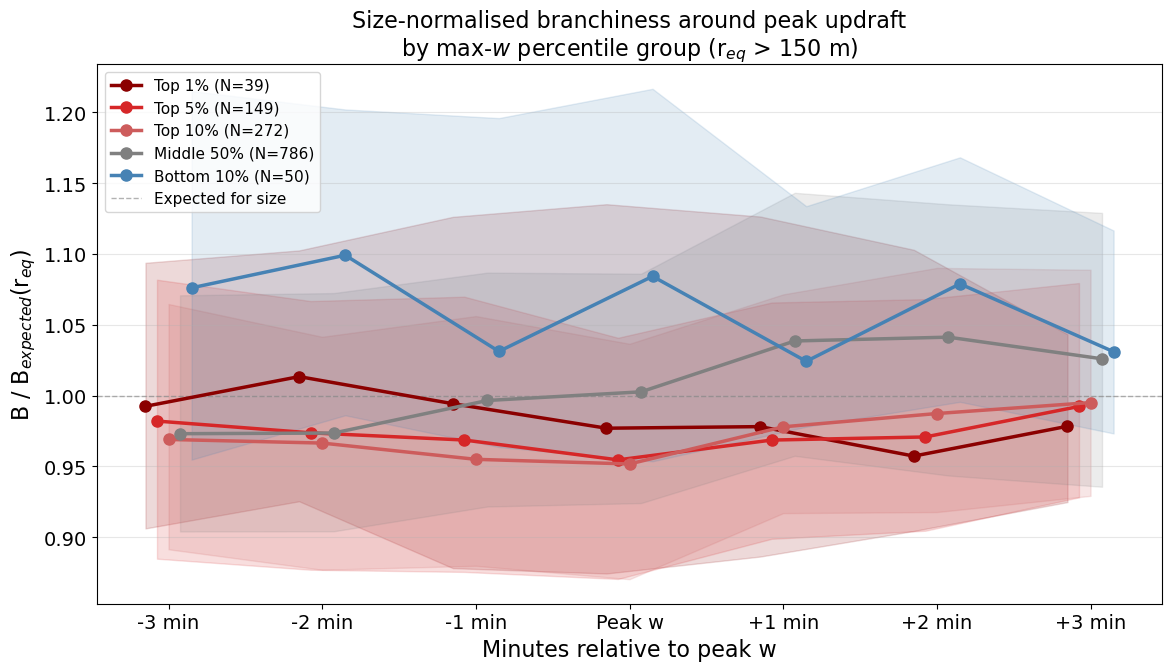



Top 1% (39 clouds):
    offset    median
    -3 min     0.9924
    -2 min     1.0134
    -1 min     0.9943
    +0 min     0.9770
    +1 min     0.9781
    +2 min     0.9573
    +3 min     0.9784
  Wilcoxon vs peak (t+0):
    t-3 → peak: Δmed=-0.0155, p=6.3383e-01 ns
    t-2 → peak: Δmed=-0.0364, p=6.4371e-01 ns
    t-1 → peak: Δmed=-0.0173, p=5.9494e-01 ns
    t+1 → peak: Δmed=-0.0011, p=2.3020e-01 ns
    t+2 → peak: Δmed=+0.0197, p=9.1759e-01 ns
    t+3 → peak: Δmed=-0.0014, p=4.7658e-01 ns

Top 5% (149 clouds):
    offset    median
    -3 min     0.9820
    -2 min     0.9737
    -1 min     0.9686
    +0 min     0.9546
    +1 min     0.9686
    +2 min     0.9708
    +3 min     0.9924
  Wilcoxon vs peak (t+0):
    t-3 → peak: Δmed=-0.0274, p=2.5354e-01 ns
    t-2 → peak: Δmed=-0.0191, p=9.0572e-01 ns
    t-1 → peak: Δmed=-0.0140, p=5.2986e-01 ns
    t+1 → peak: Δmed=-0.0140, p=2.8816e-02 *
    t+2 → peak: Δmed=-0.0162, p=3.4842e-02 *
    t+3 → peak: Δmed=-0.0377, p=1.2864e-04 ***

To

In [17]:
"""
Size-normalised branchiness around peak w — by w percentile group.

Uses B_expected_func and compute_violin_data_norm from the cell above.
Shows median ± IQR for each group at −3 min, peak w, +3 min.
"""

# ── Restrict to clouds with max r_eq > 150 m ─────────────────────────────
df_large_pct = df_section[df_section['max_r_eq'] > 150].copy()
print(f"Clouds with max r_eq > 150 m: {len(df_large_pct):,}")

# ── Define percentile groups (thresholds from the large-cloud subset) ────
max_w = df_large_pct['max_w']
groups = {
    'Top 1%':       df_large_pct[max_w >= max_w.quantile(0.99)],
    'Top 5%':       df_large_pct[max_w >= max_w.quantile(0.95)],
    'Top 10%':      df_large_pct[max_w >= max_w.quantile(0.90)],
    'Middle 50%':   df_large_pct[(max_w >= max_w.quantile(0.25)) &
                                  (max_w <  max_w.quantile(0.75))],
    'Bottom 10%':   df_large_pct[max_w <  max_w.quantile(0.10)],
}

group_colors = {
    'Top 1%':     '#8b0000',   # dark red
    'Top 5%':     '#d62728',   # red
    'Top 10%':    'indianred',
    'Middle 50%': 'grey',
    'Bottom 10%': 'steelblue',
}

MAX_OFFSET_PCT = 3
col_keys_pct = [f't{o:+d}' for o in range(-MAX_OFFSET_PCT, MAX_OFFSET_PCT + 1)]
offsets_pct  = list(range(-MAX_OFFSET_PCT, MAX_OFFSET_PCT + 1))
phase_labels_pct = [f'{o:+d} min' if o != 0 else 'Peak w' for o in offsets_pct]

# ── Compute normalised data for each group ────────────────────────────────
group_data = {}
for grp_name, df_grp in groups.items():
    df_vn = compute_violin_data_norm(df_grp, MAX_OFFSET_PCT)
    group_data[grp_name] = df_vn
    print(f"{grp_name:>15s}: {len(df_grp):>6,} clouds, "
          f"{len(df_vn):>5,} with ±{MAX_OFFSET_PCT} min data")

# ── Plot: median + IQR ribbon ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

x_pos = np.array(offsets_pct, dtype=float)
jitter = np.linspace(-0.15, 0.15, len(group_data))

for (grp_name, df_vn), dx in zip(group_data.items(), jitter):
    if len(df_vn) < 10:
        print(f"  Skipping {grp_name}: too few paired clouds ({len(df_vn)})")
        continue

    med = [df_vn[k].median() for k in col_keys_pct]
    q25 = [df_vn[k].quantile(0.25) for k in col_keys_pct]
    q75 = [df_vn[k].quantile(0.75) for k in col_keys_pct]

    c = group_colors[grp_name]
    ax.fill_between(x_pos + dx, q25, q75, alpha=0.15, color=c)
    ax.plot(x_pos + dx, med, 'o-', color=c, lw=2.5, ms=8,
            label=f'{grp_name} (N={len(df_vn):,})',
            zorder=5)

ax.axhline(1.0, color='grey', ls='--', lw=1.0, alpha=0.6, label='Expected for size')
ax.set_xticks(x_pos)
ax.set_xticklabels(phase_labels_pct)
ax.set_xlabel('Minutes relative to peak w', fontsize=FS)
ax.set_ylabel(r'B / B$_{expected}$(r$_{eq}$)', fontsize=FS)
ax.set_title('Size-normalised branchiness around peak updraft\n'
             r'by max-$w$ percentile group (r$_{eq}$ > 150 m)', fontsize=FS)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
ax.tick_params(labelsize=FS - 2)

plt.tight_layout()
plt.savefig('analysis_plots/fig_branchiness_norm_by_w_percentile.pdf',
            bbox_inches='tight', dpi=300)
plt.show()

# ── Statistics table ──────────────────────────────────────────────────────
print(f"\n{'='*70}")
sig = lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))

for grp_name, df_vn in group_data.items():
    if len(df_vn) < 10:
        continue
    print(f"\n{grp_name} ({len(df_vn)} clouds):")
    print(f"  {'offset':>8s}  {'median':>8s}")
    for o in offsets_pct:
        k = f't{o:+d}'
        print(f"  {o:>+4d} min   {df_vn[k].median():>8.4f}")
    print(f"  Wilcoxon vs peak (t+0):")
    for o in offsets_pct:
        if o == 0:
            continue
        k = f't{o:+d}'
        _, p = wilcoxon(df_vn['t+0'] - df_vn[k])
        delta = df_vn['t+0'].median() - df_vn[k].median()
        print(f"    t{o:+d} → peak: Δmed={delta:+.4f}, p={p:.4e} {sig(p)}")

### Figure 3.31b — Top-10% w vs bottom-90%: branchiness spike comparison

This comparison focuses on the branchiness time window around peak $w$ for the most vigorous tracks and for the rest of the large-cloud population.

## Figure 3.32 — Branchiness does not predict $J_i$ beyond size and lifetime

This section relates lifetime-integrated mass flux to branchiness and compares regression models with and without branchiness as an input.

- Panel (a): Hexbin of $\\log J_i$ versus mean branchiness.
- Panel (b): Standardized regression coefficients for models based on size, lifetime, max $w$, and mean branchiness.

/home/jz557/miniconda3/envs/track_env/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


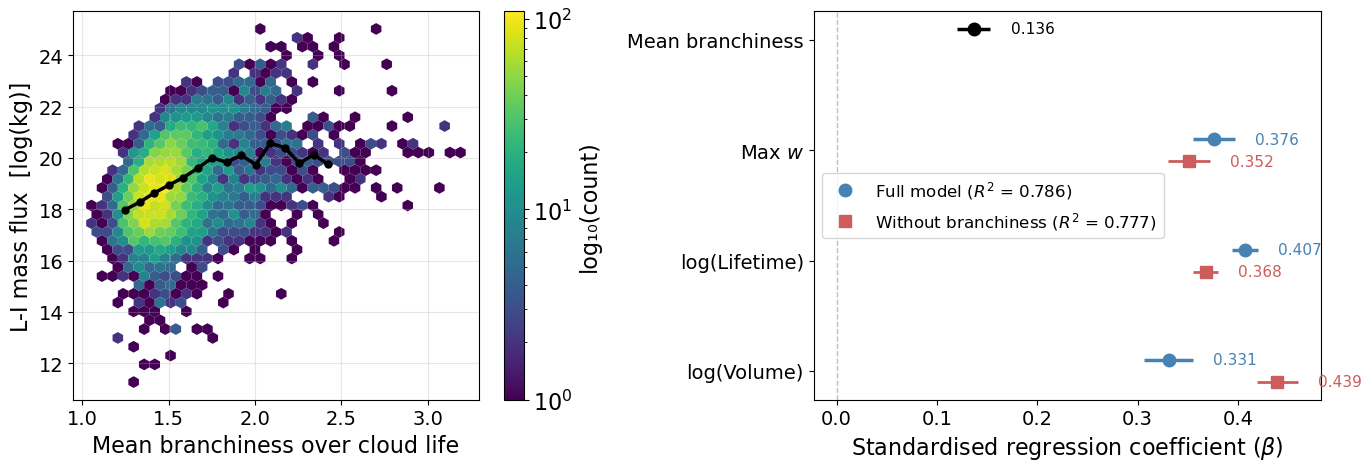


FIGURE 3.32 — REGRESSION SUMMARY
  Filter          : max r_eq > 150 m
  Clouds used (N) : 5,769
  Spearman ρ(mean_B, log J_i) = 0.3951  (p = 6.96e-215)

  FULL MODEL  (log_V, log_τ, max_w, mean_B → z(log J_i))
    R²     = 0.7862
    Adj R² = 0.7861
    AIC    = 7481.6
    F-stat = 5299.2  (p = 0.00e+00)

    Predictor                   β       SE        t            p           95% CI
    ------------------------------------------------------------------------
    log(Volume)            0.3309   0.0124    26.77    6.17e-149  [+0.3066, +0.3551]
    log(Lifetime)          0.4067   0.0067    60.31     0.00e+00  [+0.3935, +0.4200]
    Max $w$                0.3758   0.0106    35.53    2.99e-250  [+0.3551, +0.3966]
    Mean branchiness       0.1363   0.0086    15.81     3.86e-55  [+0.1194, +0.1532]

  REDUCED MODEL  (log_V, log_τ, max_w → z(log J_i))
    R²     = 0.7769
    Adj R² = 0.7768
    AIC    = 7724.4
    F-stat = 6693.3  (p = 0.00e+00)

    Predictor                   β       SE 

In [15]:
"""
Figure 3.32 — Branchiness does not predict J_i beyond size and lifetime.

Panel (a): Hexbin of log(J_i) vs mean branchiness, with running median.
Panel (b): Forest plot of standardised regression coefficients.
           Full model (with branchiness) vs reduced model (without).
           All predictors z-scored before fitting.
"""

import statsmodels.api as sm

# ── Prepare regression data ───────────────────────────────────────────────
df_reg = df_section.copy()

# Volume in m³ (from max_size × voxel_vol)
df_reg['max_vol_m3'] = df_reg['max_size'] * VOXEL_VOL

# log transforms
df_reg['log_Ji'] = np.log(df_reg['J_i'])
df_reg['log_V']  = np.log(df_reg['max_vol_m3'])
df_reg['log_tau'] = np.log(df_reg['lifetime_min'])

# Filter: r_eq > 150 m, positive J_i, finite everything
reg_mask = (
    (df_reg['max_r_eq'] > 150) &
    (df_reg['J_i'] > 0) &
    np.isfinite(df_reg['log_Ji']) &
    np.isfinite(df_reg['log_V']) &
    np.isfinite(df_reg['log_tau']) &
    np.isfinite(df_reg['max_w']) &
    np.isfinite(df_reg['mean_B']) &
    (df_reg['max_w'] > 0) &
    (df_reg['mean_B'] > 0)
)
df_reg = df_reg.loc[reg_mask].copy()

# ── Panel (a): Hexbin of log(J_i) vs mean branchiness ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                         gridspec_kw={'width_ratios': [1, 1]})

ax = axes[0]
x_p = df_reg['mean_B'].values
y_p = df_reg['log_Ji'].values

hb = ax.hexbin(x_p, y_p, gridsize=35, cmap='viridis', mincnt=1,
               norm=LogNorm(), edgecolors='none')
plt.colorbar(hb, ax=ax, label='log₁₀(count)')

# Running median
n_med = 15
be = np.linspace(np.nanpercentile(x_p, 1), np.nanpercentile(x_p, 99), n_med + 1)
bc = 0.5 * (be[:-1] + be[1:])
bd = np.digitize(x_p, be) - 1
meds = np.full(n_med, np.nan)
for b in range(n_med):
    v = y_p[bd == b]
    if len(v) >= 5:
        meds[b] = np.nanmedian(v)
ok = np.isfinite(meds)
ax.plot(bc[ok], meds[ok], 'k-o', lw=2.5, ms=5, zorder=10)

rho, p_sp = spearmanr(x_p, y_p)

ax.set_xlabel('Mean branchiness over cloud life', fontsize=FS)
ax.set_ylabel('L-I mass flux  [log(kg)]', fontsize=FS)
ax.tick_params(labelsize=FS - 2)
ax.grid(True, alpha=0.3)

# ── Panel (b): Forest plot — full vs reduced model ────────────────────────
ax = axes[1]

predictors = ['log_V', 'log_tau', 'max_w', 'mean_B']
pred_labels = ['log(Volume)', 'log(Lifetime)', 'Max $w$', 'Mean branchiness']

X_raw = df_reg[predictors].values.copy()
y_raw = df_reg['log_Ji'].values.copy()

# Z-score
X_mean = X_raw.mean(axis=0)
X_std  = X_raw.std(axis=0)
y_mean = y_raw.mean()
y_std  = y_raw.std()

X_z = (X_raw - X_mean) / X_std
y_z = (y_raw - y_mean) / y_std

# Full model (all 4 predictors)
X_full = sm.add_constant(X_z)
model_full = sm.OLS(y_z, X_full).fit()
betas_full = model_full.params[1:]
ci_full    = model_full.conf_int(alpha=0.05)[1:]
r2_full    = model_full.rsquared

# Reduced model (without branchiness)
X_reduced = sm.add_constant(X_z[:, :3])
model_reduced = sm.OLS(y_z, X_reduced).fit()
betas_reduced = model_reduced.params[1:]
ci_reduced    = model_reduced.conf_int(alpha=0.05)[1:]
r2_reduced    = model_reduced.rsquared
delta_r2 = r2_full - r2_reduced

# Plot both models side by side
y_pos = np.arange(len(predictors))
delta = 0.1  # vertical offset so points don't overlap

COL_FULL = 'steelblue'
COL_REDUCED = 'indianred'

ax.axvline(0, color='grey', linestyle='--', lw=1, alpha=0.5)

# Full model (all 4 predictors)
for j in range(len(predictors)):
    beta = betas_full[j]
    lo   = ci_full[j, 0]
    hi   = ci_full[j, 1]
    c = 'black' if j == 3 else COL_FULL  # branchiness in black
    lbl  = f'Full model ($R^2$ = {r2_full:.3f})' if j == 0 else None
    ax.plot(beta, y_pos[j] + delta, 'o', color=c, ms=9, zorder=10, label=lbl)
    ax.hlines(y_pos[j] + delta, lo, hi, color=c, lw=2.5)
    ax.text(hi + 0.02, y_pos[j] + delta, f'{beta:.3f}',
            fontsize=FS - 5, va='center', color=c)

# Reduced model (first 3 predictors only)
for j in range(3):
    beta = betas_reduced[j]
    lo   = ci_reduced[j, 0]
    hi   = ci_reduced[j, 1]
    lbl  = f'Without branchiness ($R^2$ = {r2_reduced:.3f})' if j == 0 else None
    ax.plot(beta, y_pos[j] - delta, 's', color=COL_REDUCED, ms=8, zorder=10, label=lbl)
    ax.hlines(y_pos[j] - delta, lo, hi, color=COL_REDUCED, lw=2)
    ax.text(hi + 0.02, y_pos[j] - delta, f'{beta:.3f}',
            fontsize=FS - 5, va='center', color=COL_REDUCED)

ax.set_yticks(y_pos)
ax.set_yticklabels(pred_labels, fontsize=FS - 2)
ax.set_xlabel('Standardised regression coefficient ($\\beta$)', fontsize=FS)
ax.tick_params(labelsize=FS - 2)
ax.legend(fontsize=FS - 4, loc='center left')

plt.tight_layout()
plt.savefig('analysis_plots/fig_3_32_Ji_vs_branchiness.pdf', bbox_inches='tight', dpi=300)
plt.show()

# ── Print full summary ────────────────────────────────────────────────────
print("\n" + "="*70)
print("FIGURE 3.32 — REGRESSION SUMMARY")
print("="*70)
print(f"  Filter          : max r_eq > 150 m")
print(f"  Clouds used (N) : {len(df_reg):,}")
print(f"  Spearman ρ(mean_B, log J_i) = {rho:.4f}  (p = {p_sp:.2e})")

print(f"\n  FULL MODEL  (log_V, log_τ, max_w, mean_B → z(log J_i))")
print(f"    R²     = {r2_full:.4f}")
print(f"    Adj R² = {model_full.rsquared_adj:.4f}")
print(f"    AIC    = {model_full.aic:.1f}")
print(f"    F-stat = {model_full.fvalue:.1f}  (p = {model_full.f_pvalue:.2e})")
print(f"\n    {'Predictor':<20s} {'β':>8s} {'SE':>8s} {'t':>8s} {'p':>12s} {'95% CI':>16s}")
print(f"    {'-'*72}")
for j, lab in enumerate(pred_labels):
    b  = betas_full[j]
    se = model_full.bse[j+1]
    t  = model_full.tvalues[j+1]
    p  = model_full.pvalues[j+1]
    lo = ci_full[j, 0]
    hi = ci_full[j, 1]
    print(f"    {lab:<20s} {b:>8.4f} {se:>8.4f} {t:>8.2f} {p:>12.2e}  [{lo:+.4f}, {hi:+.4f}]")

print(f"\n  REDUCED MODEL  (log_V, log_τ, max_w → z(log J_i))")
print(f"    R²     = {r2_reduced:.4f}")
print(f"    Adj R² = {model_reduced.rsquared_adj:.4f}")
print(f"    AIC    = {model_reduced.aic:.1f}")
print(f"    F-stat = {model_reduced.fvalue:.1f}  (p = {model_reduced.f_pvalue:.2e})")
pred_labels_r = pred_labels[:3]
print(f"\n    {'Predictor':<20s} {'β':>8s} {'SE':>8s} {'t':>8s} {'p':>12s} {'95% CI':>16s}")
print(f"    {'-'*72}")
for j, lab in enumerate(pred_labels_r):
    b  = betas_reduced[j]
    se = model_reduced.bse[j+1]
    t  = model_reduced.tvalues[j+1]
    p  = model_reduced.pvalues[j+1]
    lo = ci_reduced[j, 0]
    hi = ci_reduced[j, 1]
    print(f"    {lab:<20s} {b:>8.4f} {se:>8.4f} {t:>8.2f} {p:>12.2e}  [{lo:+.4f}, {hi:+.4f}]")

print(f"\n  ΔR² from adding branchiness: {delta_r2:.5f}")
if delta_r2 < 0.01:
    print("  → Branchiness adds < 1% variance — negligible independent contribution.")
else:
    print(f"  → Branchiness adds {delta_r2*100:.2f}% variance.")

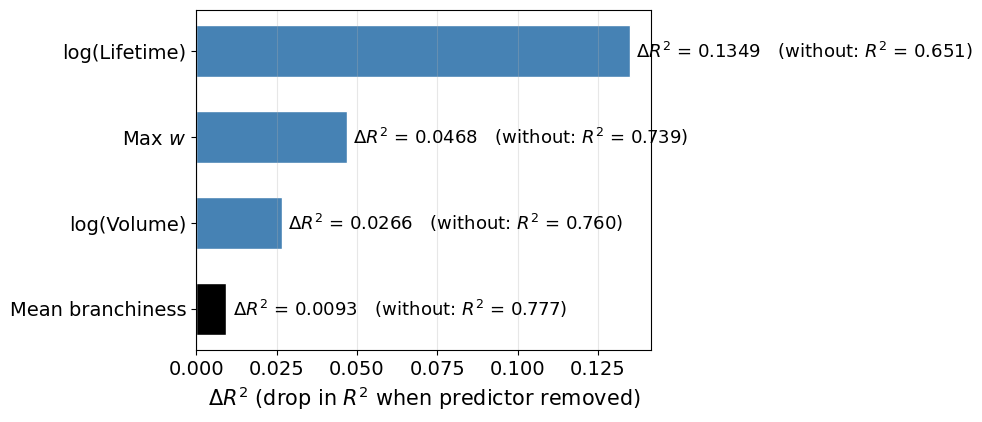

LEAVE-ONE-OUT PREDICTOR IMPORTANCE
  Full model R² = 0.7862  (all 4 predictors)

  Dropped predictor        R² without        ΔR²   % of full R²
  ------------------------------------------------------------
  log(Lifetime)                0.6513     0.1349          17.2%
  Max $w$                      0.7394     0.0468           6.0%
  log(Volume)                  0.7596     0.0266           3.4%
  Mean branchiness             0.7769     0.0093           1.2%


In [18]:
"""
Leave-one-out predictor importance for log(J_i) regression.

Runs the full 4-predictor model once, then drops each predictor in turn.
Shows ΔR² (the R² lost by removing that predictor) as a horizontal bar chart —
this is the unique variance each predictor explains beyond the other three.
"""

# ── Leave-one-out models ──────────────────────────────────────────────────
results = []
for k in range(len(predictors)):
    cols_keep = [c for c in range(len(predictors)) if c != k]
    X_loo = sm.add_constant(X_z[:, cols_keep])
    model_loo = sm.OLS(y_z, X_loo).fit()
    drop_r2 = r2_full - model_loo.rsquared
    results.append({
        'predictor': pred_labels[k],
        'r2_without': model_loo.rsquared,
        'delta_r2': drop_r2,
        'adj_r2_without': model_loo.rsquared_adj,
    })

# Sort by ΔR² ascending (smallest at bottom for horizontal bars)
results.sort(key=lambda x: x['delta_r2'])

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4.5))

labels = [r['predictor'] for r in results]
deltas = [r['delta_r2'] for r in results]
r2s    = [r['r2_without'] for r in results]

y_pos = np.arange(len(results))
bar_colors = ['black' if 'branchiness' in lab.lower() else 'steelblue' for lab in labels]

bars = ax.barh(y_pos, deltas, color=bar_colors, edgecolor='white', height=0.6)

# Annotate each bar
for i, (d, r2_wo) in enumerate(zip(deltas, r2s)):
    ax.text(d + 0.002, i, f'$\\Delta R^2$ = {d:.4f}   (without: $R^2$ = {r2_wo:.3f})',
            va='center', fontsize=FS - 3)

ax.axvline(0, color='grey', lw=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=FS - 2)
ax.set_xlabel(f'$\\Delta R^2$ (drop in $R^2$ when predictor removed)', fontsize=FS - 1)
ax.tick_params(labelsize=FS - 2)
ax.set_xlim(left=0)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('analysis_plots/fig_3_32b_leave_one_out.pdf', bbox_inches='tight', dpi=300)
plt.show()

# ── Print summary table ───────────────────────────────────────────────────
print("="*70)
print("LEAVE-ONE-OUT PREDICTOR IMPORTANCE")
print("="*70)
print(f"  Full model R² = {r2_full:.4f}  (all 4 predictors)")
print(f"\n  {'Dropped predictor':<22s} {'R² without':>12s} {'ΔR²':>10s} {'% of full R²':>14s}")
print(f"  {'-'*60}")
for r in sorted(results, key=lambda x: -x['delta_r2']):
    pct = r['delta_r2'] / r2_full * 100
    print(f"  {r['predictor']:<22s} {r['r2_without']:>12.4f} {r['delta_r2']:>10.4f} {pct:>13.1f}%")

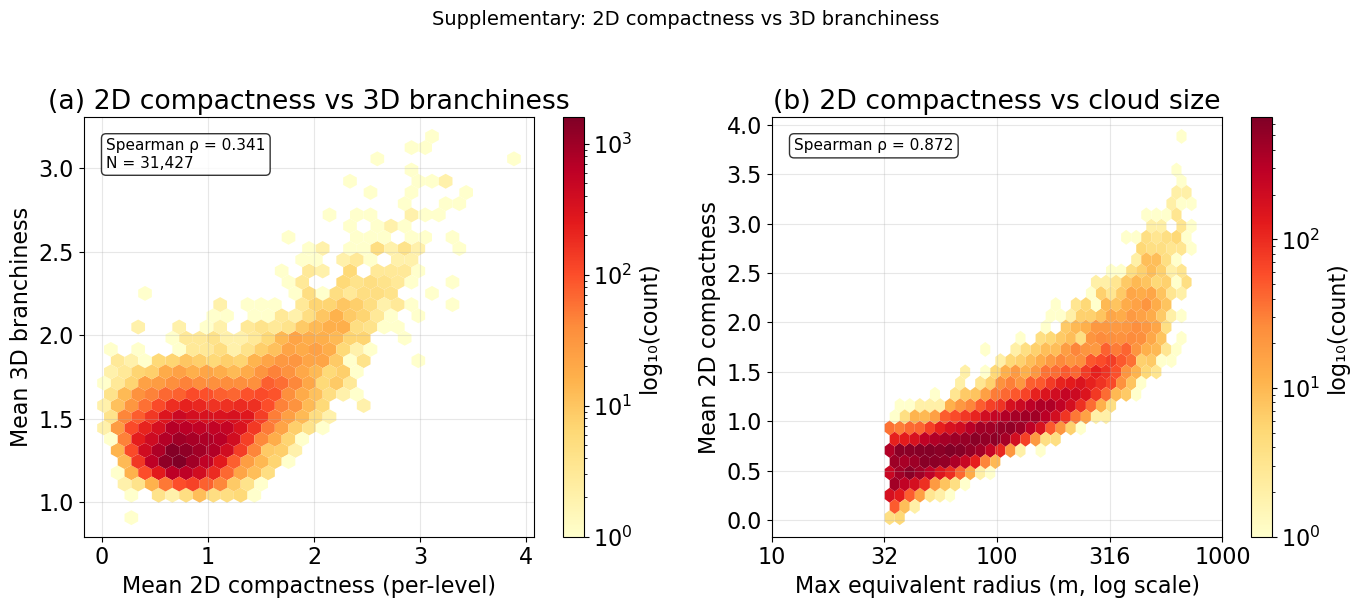


Correlation between 2D compactness and 3D branchiness:
  Spearman ρ = 0.341 (p = 0.00e+00)

Correlation between 2D compactness and size:
  Spearman ρ = 0.872 (p = 0.00e+00)


In [46]:
"""
Supplementary: 2D compactness per level vs 3D branchiness.

Computes a height-averaged compactness per cloud track (the mean of
compactness_per_level over all levels with cloud present, averaged over time)
and compares it to the 3D branchiness metric.

Two plots:
  (a) Hexbin: mean 2D compactness vs 3D branchiness.
  (b) Hexbin: mean 2D compactness vs max equivalent radius.
"""

# ── Compute per-track mean 2D compactness ─────────────────────────────────
# compactness_per_level is (track, time, level). We want the mean over all
# cloud-containing levels and active timesteps.

comp_data = raw['compactness_per_level']   # (n_tracks, n_time, n_levels)

mean_compactness_list = []
track_indices_list    = []

for _, row in df_section.iterrows():
    i = int(row['track_index'])
    size_row = raw['size'][i]
    active_idx = np.where(np.isfinite(size_row) & (size_row > 0))[0]
    if len(active_idx) == 0:
        continue

    # comp_data[i, active_idx, :] has shape (n_active, n_levels)
    # Values are NaN where cloud doesn't exist at that level
    comp_slice = comp_data[i, active_idx, :]

    # Mean over all finite (cloud-containing) entries
    finite_vals = comp_slice[np.isfinite(comp_slice)]
    if len(finite_vals) == 0:
        mean_compactness_list.append(np.nan)
    else:
        mean_compactness_list.append(float(np.nanmean(finite_vals)))
    track_indices_list.append(i)

df_section['mean_compactness_2d'] = np.nan
idx_map = {ti: j for j, ti in enumerate(track_indices_list)}
for _, row in df_section.iterrows():
    i = int(row['track_index'])
    if i in idx_map:
        df_section.loc[df_section['track_index'] == i, 'mean_compactness_2d'] = \
            mean_compactness_list[idx_map[i]]

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

mask = np.isfinite(df_section['mean_compactness_2d']) & np.isfinite(df_section['mean_B'])

# (a) 2D compactness vs 3D branchiness
ax = axes[0]
x_c = df_section.loc[mask, 'mean_compactness_2d'].values
y_c = df_section.loc[mask, 'mean_B'].values
hb = ax.hexbin(x_c, y_c, gridsize=30, cmap='YlOrRd', mincnt=1,
               norm=LogNorm(), edgecolors='none')
plt.colorbar(hb, ax=ax, label='log₁₀(count)')
rho, p = spearmanr(x_c, y_c)
ax.text(0.05, 0.95, f'Spearman ρ = {rho:.3f}\nN = {mask.sum():,}',
        transform=ax.transAxes, fontsize=11, va='top',
        bbox=dict(boxstyle='round', fc='white', alpha=0.8))
ax.set_xlabel('Mean 2D compactness (per-level)')
ax.set_ylabel('Mean 3D branchiness')
ax.set_title('(a) 2D compactness vs 3D branchiness')
ax.grid(True, alpha=0.3)

# (b) 2D compactness vs size
ax = axes[1]
mask2 = mask & (df_section['max_r_eq'] > 0)
x_r = np.log10(df_section.loc[mask2, 'max_r_eq'].values)
y_r = df_section.loc[mask2, 'mean_compactness_2d'].values
hb = ax.hexbin(x_r, y_r, gridsize=30, cmap='YlOrRd', mincnt=1,
               norm=LogNorm(), edgecolors='none')
plt.colorbar(hb, ax=ax, label='log₁₀(count)')
rho2, p2 = spearmanr(x_r, y_r)
ax.text(0.05, 0.95, f'Spearman ρ = {rho2:.3f}',
        transform=ax.transAxes, fontsize=11, va='top',
        bbox=dict(boxstyle='round', fc='white', alpha=0.8))
xtv = [1.0, 1.5, 2.0, 2.5, 3.0]
ax.set_xticks(xtv)
ax.set_xticklabels([f'{10**v:.0f}' for v in xtv])
ax.set_xlabel('Max equivalent radius (m, log scale)')
ax.set_ylabel('Mean 2D compactness')
ax.set_title('(b) 2D compactness vs cloud size')
ax.grid(True, alpha=0.3)

plt.suptitle('Supplementary: 2D compactness vs 3D branchiness', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('analysis_plots/fig_supp_compactness_vs_branchiness.pdf', bbox_inches='tight', dpi=300)
plt.show()

print(f"\nCorrelation between 2D compactness and 3D branchiness:")
print(f"  Spearman ρ = {rho:.3f} (p = {p:.2e})")
print(f"\nCorrelation between 2D compactness and size:")
print(f"  Spearman ρ = {rho2:.3f} (p = {p2:.2e})")

### Additional checks

- Add cloud-top height to the regression model.
- Repeat the peak-$w$ window comparison for detached and non-detached tracks.
- Refit the regression using only larger clouds.

max_height_m: 31,427 / 31,427 finite
  median = 1062 m,  IQR = [812, 1388]
Regression sample (with height): 22,670 clouds


/home/jz557/miniconda3/envs/track_env/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


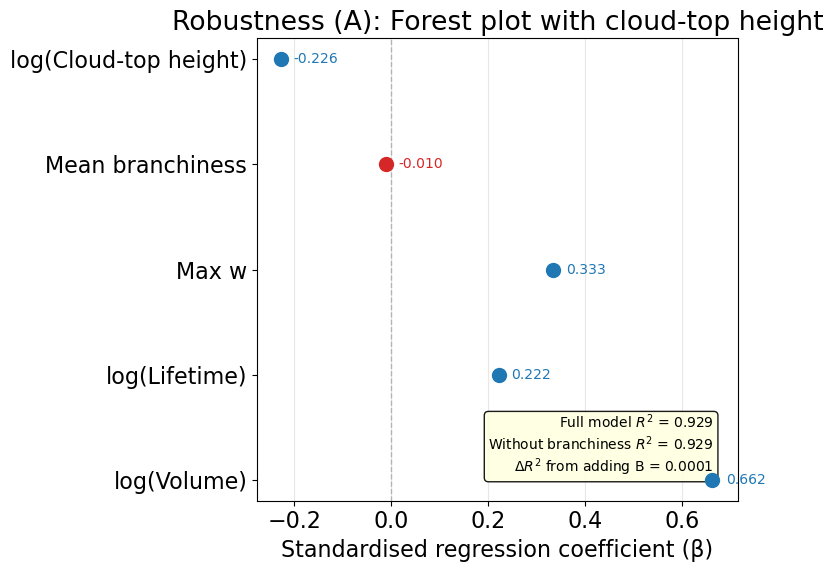


ROBUSTNESS (A): REGRESSION WITH CLOUD-TOP HEIGHT (z-scored)
  N = 22,670
  R² = 0.9293,  Adj R² = 0.9293

  Predictor                        β       SE        t            p
  ---------------------------------------------------------------
  log(Volume)                 0.6616   0.0043   155.34     0.00e+00
  log(Lifetime)               0.2220   0.0023    95.37     0.00e+00
  Max w                       0.3331   0.0041    81.19     0.00e+00
  Mean branchiness           -0.0102   0.0020    -4.98     6.28e-07
  log(Cloud-top height)      -0.2265   0.0027   -83.69     0.00e+00

  ΔR² from adding branchiness: 0.00008
  → Branchiness adds < 1% variance — negligible even after controlling for cloud-top height.


In [47]:
"""
Robustness check (A) — Forest plot with cloud-top height as 5th predictor.

Model: log J_i = β₀ + β₁·log V + β₂·log τ + β₃·max_w + β₄·mean_B + β₅·log(H_top) + ε
All predictors z-scored.
"""

import statsmodels.api as sm

# ── Compute per-track max cloud-top height from raw arrays ────────────────
max_ht_per_track = []
for _, row in df_section.iterrows():
    i = int(row['track_index'])
    ht = raw['max_height'][i, :]
    size_row = raw['size'][i, :]
    active = np.isfinite(size_row) & (size_row > 0)
    ht_active = ht[active]
    val = float(np.nanmax(ht_active)) if np.any(np.isfinite(ht_active)) else np.nan
    max_ht_per_track.append(val)

df_section['max_height_m'] = max_ht_per_track
print(f"max_height_m: {df_section['max_height_m'].notna().sum():,} / {len(df_section):,} finite")
print(f"  median = {df_section['max_height_m'].median():.0f} m,  "
      f"IQR = [{df_section['max_height_m'].quantile(0.25):.0f}, "
      f"{df_section['max_height_m'].quantile(0.75):.0f}]")

# ── Prepare regression data ───────────────────────────────────────────────
df_reg_h = df_section.copy()
df_reg_h['max_vol_m3'] = df_reg_h['max_size'] * VOXEL_VOL
df_reg_h['log_Ji']  = np.log(df_reg_h['J_i'])
df_reg_h['log_V']   = np.log(df_reg_h['max_vol_m3'])
df_reg_h['log_tau'] = np.log(df_reg_h['lifetime_min'])
df_reg_h['log_H']   = np.log(df_reg_h['max_height_m'])

reg_mask_h = (
    (df_reg_h['J_i'] > 0) &
    np.isfinite(df_reg_h['log_Ji']) &
    np.isfinite(df_reg_h['log_V']) &
    np.isfinite(df_reg_h['log_tau']) &
    np.isfinite(df_reg_h['max_w']) &
    np.isfinite(df_reg_h['mean_B']) &
    np.isfinite(df_reg_h['log_H']) &
    (df_reg_h['max_w'] > 0) &
    (df_reg_h['mean_B'] > 0) &
    (df_reg_h['max_height_m'] > 0)
)
df_reg_h = df_reg_h.loc[reg_mask_h].copy()
print(f"Regression sample (with height): {len(df_reg_h):,} clouds")

# ── Z-score and fit ──────────────────────────────────────────────────────
predictors_h = ['log_V', 'log_tau', 'max_w', 'mean_B', 'log_H']
pred_labels_h = ['log(Volume)', 'log(Lifetime)', 'Max w', 'Mean branchiness', 'log(Cloud-top height)']

X_raw_h = df_reg_h[predictors_h].values.copy()
y_raw_h = df_reg_h['log_Ji'].values.copy()

X_mean_h = X_raw_h.mean(axis=0)
X_std_h  = X_raw_h.std(axis=0)
y_mean_h = y_raw_h.mean()
y_std_h  = y_raw_h.std()

X_z_h = (X_raw_h - X_mean_h) / X_std_h
y_z_h = (y_raw_h - y_mean_h) / y_std_h

# Full model (5 predictors)
X_full_h = sm.add_constant(X_z_h)
model_full_h = sm.OLS(y_z_h, X_full_h).fit()
betas_full_h = model_full_h.params[1:]
ci_full_h    = model_full_h.conf_int(alpha=0.05)[1:]
r2_full_h    = model_full_h.rsquared

# Reduced model (without branchiness — drop column index 3)
keep_cols = [0, 1, 2, 4]  # log_V, log_tau, max_w, log_H
X_reduced_h = sm.add_constant(X_z_h[:, keep_cols])
model_reduced_h = sm.OLS(y_z_h, X_reduced_h).fit()
r2_reduced_h = model_reduced_h.rsquared
delta_r2_h = r2_full_h - r2_reduced_h

# ── Forest plot ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

y_pos_h = np.arange(len(predictors_h))
colors_h = ['C0', 'C0', 'C0', 'C3', 'C0']

ax.axvline(0, color='grey', linestyle='--', lw=1, alpha=0.5)

for j in range(len(predictors_h)):
    beta = betas_full_h[j]
    lo = ci_full_h[j, 0]
    hi = ci_full_h[j, 1]
    ax.plot(beta, y_pos_h[j], 'o', color=colors_h[j], ms=10, zorder=10)
    ax.hlines(y_pos_h[j], lo, hi, color=colors_h[j], lw=2.5)
    ax.text(hi + 0.02, y_pos_h[j], f'{beta:.3f}',
            fontsize=10, va='center', color=colors_h[j])

ax.set_yticks(y_pos_h)
ax.set_yticklabels(pred_labels_h)
ax.set_xlabel('Standardised regression coefficient (β)')
ax.set_title('Robustness (A): Forest plot with cloud-top height')
ax.grid(True, alpha=0.3, axis='x')

textstr_h = (f'Full model $R^2$ = {r2_full_h:.3f}\n'
             f'Without branchiness $R^2$ = {r2_reduced_h:.3f}\n'
             f'$\\Delta R^2$ from adding B = {delta_r2_h:.4f}')
ax.text(0.95, 0.05, textstr_h, transform=ax.transAxes, fontsize=10,
        va='bottom', ha='right', bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.9))

plt.tight_layout()
plt.savefig('analysis_plots/fig_robustness_A_forest_with_height.pdf', bbox_inches='tight', dpi=300)
plt.show()

# ── Print regression summary ─────────────────────────────────────────────
print(f"\n{'='*70}")
print(f"ROBUSTNESS (A): REGRESSION WITH CLOUD-TOP HEIGHT (z-scored)")
print(f"{'='*70}")
print(f"  N = {len(df_reg_h):,}")
print(f"  R² = {r2_full_h:.4f},  Adj R² = {model_full_h.rsquared_adj:.4f}")
print(f"\n  {'Predictor':<25s} {'β':>8s} {'SE':>8s} {'t':>8s} {'p':>12s}")
print(f"  {'-'*63}")
for j, lab in enumerate(pred_labels_h):
    b  = betas_full_h[j]
    se = model_full_h.bse[j+1]
    t  = model_full_h.tvalues[j+1]
    p  = model_full_h.pvalues[j+1]
    print(f"  {lab:<25s} {b:>8.4f} {se:>8.4f} {t:>8.2f} {p:>12.2e}")
print(f"\n  ΔR² from adding branchiness: {delta_r2_h:.5f}")
if delta_r2_h < 0.01:
    print("  → Branchiness adds < 1% variance — negligible even after controlling for cloud-top height.")

Detached clouds : 6,167
Attached clouds : 25,260

Top-10% w thresholds:
  Detached : 4.05 m/s  (617 clouds)
  Attached : 2.50 m/s  (2,526 clouds)

Paired clouds with ±2 min bracket:
  Detached : 421
  Attached : 923


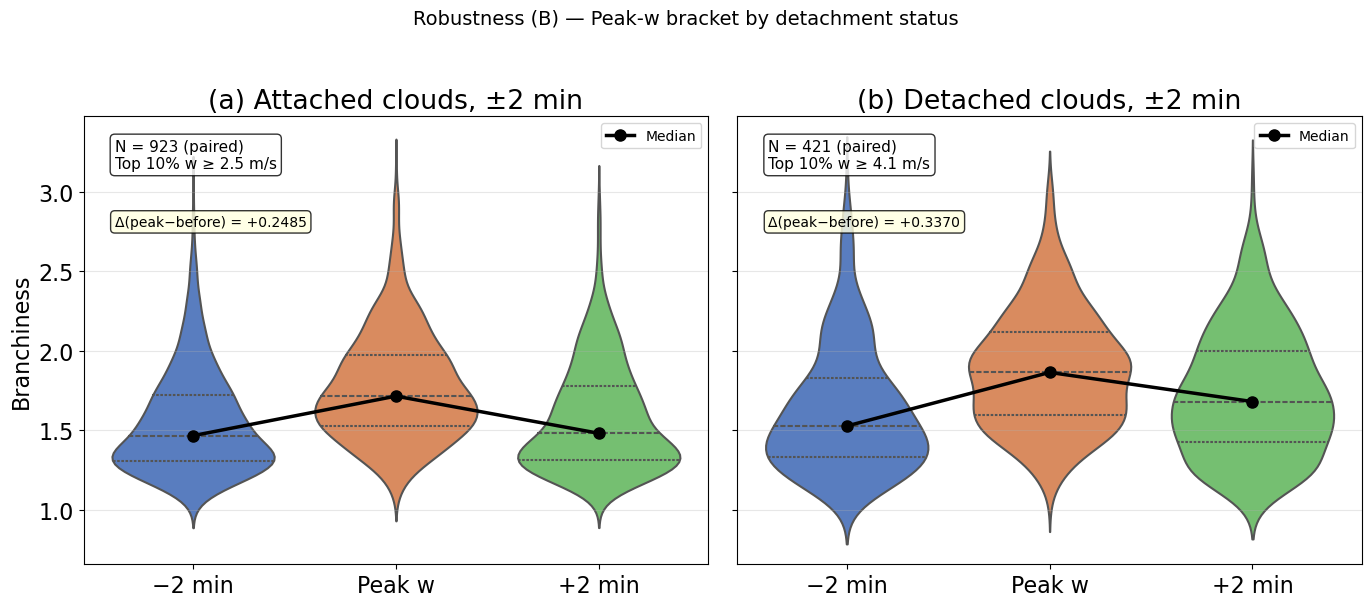


ROBUSTNESS (B): DETACHMENT SUBSET VIOLIN STATISTICS

  Attached (N = 923 paired):
    Before : median = 1.4667
    Peak   : median = 1.7152
    After  : median = 1.4818
    Δ(peak − before) = +0.2485
    Wilcoxon before→peak : p = 8.8901e-72

  Detached (N = 421 paired):
    Before : median = 1.5274
    Peak   : median = 1.8644
    After  : median = 1.6810
    Δ(peak − before) = +0.3370
    Wilcoxon before→peak : p = 2.1278e-34

  Mann-Whitney U (peak B, attached vs detached): p = 3.1973e-07


In [48]:
"""
Robustness check (B) — Does the contemporaneous peak-w bracket
differ for detached vs non-detached clouds?

Uses ±2 min offset, top-10% w within each sub-population.
"""

from scipy.stats import wilcoxon, mannwhitneyu

# ── Split by detachment status ────────────────────────────────────────────
df_det  = df_section.loc[df_section['is_detached'] == True].copy()
df_att  = df_section.loc[df_section['is_detached'] == False].copy()
print(f"Detached clouds : {len(df_det):,}")
print(f"Attached clouds : {len(df_att):,}")

# ── Top-10% w within each subpopulation ───────────────────────────────────
w90_det = df_det['max_w'].quantile(0.90)
w90_att = df_att['max_w'].quantile(0.90)
df_det_top10 = df_det.loc[df_det['max_w'] >= w90_det]
df_att_top10 = df_att.loc[df_att['max_w'] >= w90_att]
print(f"\nTop-10% w thresholds:")
print(f"  Detached : {w90_det:.2f} m/s  ({len(df_det_top10):,} clouds)")
print(f"  Attached : {w90_att:.2f} m/s  ({len(df_att_top10):,} clouds)")

offset = 2  # minutes

df_v_det = compute_violin_data_subset(df_det_top10, offset)
df_v_att = compute_violin_data_subset(df_att_top10, offset)
print(f"\nPaired clouds with ±{offset} min bracket:")
print(f"  Detached : {len(df_v_det):,}")
print(f"  Attached : {len(df_v_att):,}")

# ── Plot: side-by-side violin panels ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax_i, (ax, df_v, label, n_clouds, w_thr) in enumerate(zip(
    axes,
    [df_v_att, df_v_det],
    ['Attached', 'Detached'],
    [len(df_att_top10), len(df_det_top10)],
    [w90_att, w90_det]
)):
    panel = '(a)' if ax_i == 0 else '(b)'
    df_long = pd.DataFrame({
        'Branchiness': np.concatenate([df_v['before'], df_v['peak'], df_v['after']]),
        'Phase': ([f'−{offset} min'] * len(df_v) +
                  ['Peak w'] * len(df_v) +
                  [f'+{offset} min'] * len(df_v))
    })
    phase_order = [f'−{offset} min', 'Peak w', f'+{offset} min']

    sns.violinplot(data=df_long, x='Phase', y='Branchiness',
                   hue='Phase', order=phase_order, hue_order=phase_order,
                   inner='quartile', palette='muted', linewidth=1.5,
                   legend=False, ax=ax)

    meds = [df_v['before'].median(), df_v['peak'].median(), df_v['after'].median()]
    ax.plot([0, 1, 2], meds, 'ko-', lw=2.5, ms=8, zorder=10, label='Median')

    ax.text(0.05, 0.95, f'N = {len(df_v):,} (paired)\nTop 10% w ≥ {w_thr:.1f} m/s',
            transform=ax.transAxes, fontsize=11, va='top',
            bbox=dict(boxstyle='round', fc='white', alpha=0.8))

    delta_bp = df_v['peak'].median() - df_v['before'].median()
    ax.text(0.05, 0.78, f'Δ(peak−before) = {delta_bp:+.4f}',
            transform=ax.transAxes, fontsize=10, va='top',
            bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.8))

    ax.set_xlabel('')
    if ax_i == 0:
        ax.set_ylabel('Branchiness')
    ax.set_title(f'{panel} {label} clouds, ±{offset} min')
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Robustness (B) — Peak-w bracket by detachment status',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('analysis_plots/fig_robustness_B_detachment_violins.pdf', bbox_inches='tight', dpi=300)
plt.show()

# ── Statistics ────────────────────────────────────────────────────────────
print(f"\n{'='*70}")
print(f"ROBUSTNESS (B): DETACHMENT SUBSET VIOLIN STATISTICS")
print(f"{'='*70}")
for label, df_v in [('Attached', df_v_att), ('Detached', df_v_det)]:
    print(f"\n  {label} (N = {len(df_v):,} paired):")
    print(f"    Before : median = {df_v['before'].median():.4f}")
    print(f"    Peak   : median = {df_v['peak'].median():.4f}")
    print(f"    After  : median = {df_v['after'].median():.4f}")
    delta = df_v['peak'].median() - df_v['before'].median()
    print(f"    Δ(peak − before) = {delta:+.4f}")
    if len(df_v) >= 10:
        stat, p = wilcoxon(df_v['peak'] - df_v['before'])
        print(f"    Wilcoxon before→peak : p = {p:.4e}")

# Compare the peak branchiness between attached and detached
if len(df_v_att) >= 5 and len(df_v_det) >= 5:
    stat_mw, p_mw = mannwhitneyu(df_v_att['peak'], df_v_det['peak'], alternative='two-sided')
    print(f"\n  Mann-Whitney U (peak B, attached vs detached): p = {p_mw:.4e}")

Large clouds (r_eq > 150 m): 6,280 / 31,427
Regression sample (large clouds): 5,769


/home/jz557/miniconda3/envs/track_env/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


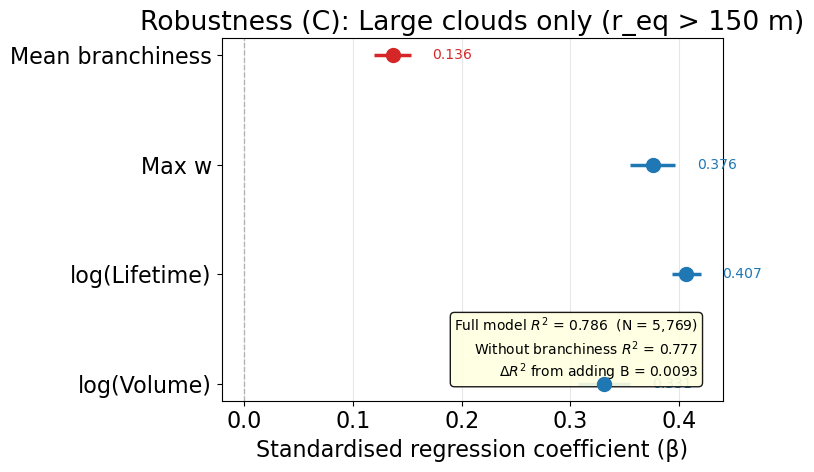


ROBUSTNESS (C): LARGE CLOUDS ONLY (r_eq > 150 m)
  N = 5,769
  R² = 0.7862,  Adj R² = 0.7861

  Predictor                   β       SE        t            p
  ----------------------------------------------------------
  log(Volume)            0.3309   0.0124    26.77    6.17e-149
  log(Lifetime)          0.4067   0.0067    60.31     0.00e+00
  Max w                  0.3758   0.0106    35.53    2.99e-250
  Mean branchiness       0.1363   0.0086    15.81     3.86e-55

  ΔR² from adding branchiness: 0.00927

  Comparison with full-population Fig 3.32:
    Full pop  ΔR² = 0.00004  (N = 22,670)
    Large only ΔR² = 0.00927  (N = 5,769)
  → Branchiness remains negligible even when restricted to large clouds.


In [49]:
"""
Robustness check (C) — Forest plot restricted to large clouds (r_eq > 150 m).

Same model as Fig 3.32(b) but on a subset of ~11,500 clouds with
max equivalent radius > 150 m.  Tests whether the null branchiness
result is an artefact of including many tiny clouds.
"""

import statsmodels.api as sm

REQ_THRESHOLD = 150.0  # m

df_large = df_section.loc[df_section['max_r_eq'] > REQ_THRESHOLD].copy()
print(f"Large clouds (r_eq > {REQ_THRESHOLD:.0f} m): {len(df_large):,} / {len(df_section):,}")

# ── Prepare regression data ───────────────────────────────────────────────
df_reg_l = df_large.copy()
df_reg_l['max_vol_m3'] = df_reg_l['max_size'] * VOXEL_VOL
df_reg_l['log_Ji']  = np.log(df_reg_l['J_i'])
df_reg_l['log_V']   = np.log(df_reg_l['max_vol_m3'])
df_reg_l['log_tau'] = np.log(df_reg_l['lifetime_min'])

reg_mask_l = (
    (df_reg_l['J_i'] > 0) &
    np.isfinite(df_reg_l['log_Ji']) &
    np.isfinite(df_reg_l['log_V']) &
    np.isfinite(df_reg_l['log_tau']) &
    np.isfinite(df_reg_l['max_w']) &
    np.isfinite(df_reg_l['mean_B']) &
    (df_reg_l['max_w'] > 0) &
    (df_reg_l['mean_B'] > 0)
)
df_reg_l = df_reg_l.loc[reg_mask_l].copy()
print(f"Regression sample (large clouds): {len(df_reg_l):,}")

# ── Z-score and fit ──────────────────────────────────────────────────────
predictors_l = ['log_V', 'log_tau', 'max_w', 'mean_B']
pred_labels_l = ['log(Volume)', 'log(Lifetime)', 'Max w', 'Mean branchiness']

X_raw_l = df_reg_l[predictors_l].values.copy()
y_raw_l = df_reg_l['log_Ji'].values.copy()

X_mean_l = X_raw_l.mean(axis=0)
X_std_l  = X_raw_l.std(axis=0)
y_mean_l = y_raw_l.mean()
y_std_l  = y_raw_l.std()

X_z_l = (X_raw_l - X_mean_l) / X_std_l
y_z_l = (y_raw_l - y_mean_l) / y_std_l

# Full model
X_full_l = sm.add_constant(X_z_l)
model_full_l = sm.OLS(y_z_l, X_full_l).fit()
betas_full_l = model_full_l.params[1:]
ci_full_l    = model_full_l.conf_int(alpha=0.05)[1:]
r2_full_l    = model_full_l.rsquared

# Reduced model (without branchiness)
X_reduced_l = sm.add_constant(X_z_l[:, :3])
model_reduced_l = sm.OLS(y_z_l, X_reduced_l).fit()
r2_reduced_l = model_reduced_l.rsquared
delta_r2_l = r2_full_l - r2_reduced_l

# ── Forest plot ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

y_pos_l = np.arange(len(predictors_l))
colors_l = ['C0', 'C0', 'C0', 'C3']

ax.axvline(0, color='grey', linestyle='--', lw=1, alpha=0.5)

for j in range(len(predictors_l)):
    beta = betas_full_l[j]
    lo = ci_full_l[j, 0]
    hi = ci_full_l[j, 1]
    ax.plot(beta, y_pos_l[j], 'o', color=colors_l[j], ms=10, zorder=10)
    ax.hlines(y_pos_l[j], lo, hi, color=colors_l[j], lw=2.5)
    ax.text(hi + 0.02, y_pos_l[j], f'{beta:.3f}',
            fontsize=10, va='center', color=colors_l[j])

ax.set_yticks(y_pos_l)
ax.set_yticklabels(pred_labels_l)
ax.set_xlabel('Standardised regression coefficient (β)')
ax.set_title(f'Robustness (C): Large clouds only (r_eq > {REQ_THRESHOLD:.0f} m)')
ax.grid(True, alpha=0.3, axis='x')

textstr_l = (f'Full model $R^2$ = {r2_full_l:.3f}  (N = {len(df_reg_l):,})\n'
             f'Without branchiness $R^2$ = {r2_reduced_l:.3f}\n'
             f'$\\Delta R^2$ from adding B = {delta_r2_l:.4f}')
ax.text(0.95, 0.05, textstr_l, transform=ax.transAxes, fontsize=10,
        va='bottom', ha='right', bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.9))

plt.tight_layout()
plt.savefig('analysis_plots/fig_robustness_C_large_clouds_forest.pdf', bbox_inches='tight', dpi=300)
plt.show()

# ── Print regression summary ─────────────────────────────────────────────
print(f"\n{'='*70}")
print(f"ROBUSTNESS (C): LARGE CLOUDS ONLY (r_eq > {REQ_THRESHOLD:.0f} m)")
print(f"{'='*70}")
print(f"  N = {len(df_reg_l):,}")
print(f"  R² = {r2_full_l:.4f},  Adj R² = {model_full_l.rsquared_adj:.4f}")
print(f"\n  {'Predictor':<20s} {'β':>8s} {'SE':>8s} {'t':>8s} {'p':>12s}")
print(f"  {'-'*58}")
for j, lab in enumerate(pred_labels_l):
    b  = betas_full_l[j]
    se = model_full_l.bse[j+1]
    t  = model_full_l.tvalues[j+1]
    p  = model_full_l.pvalues[j+1]
    print(f"  {lab:<20s} {b:>8.4f} {se:>8.4f} {t:>8.2f} {p:>12.2e}")
print(f"\n  ΔR² from adding branchiness: {delta_r2_l:.5f}")

# Compare with full-population result
print(f"\n  Comparison with full-population Fig 3.32:")
print(f"    Full pop  ΔR² = {delta_r2:.5f}  (N = {len(df_reg):,})")
print(f"    Large only ΔR² = {delta_r2_l:.5f}  (N = {len(df_reg_l):,})")
if delta_r2_l < 0.01:
    print("  → Branchiness remains negligible even when restricted to large clouds.")